# 04 — Predicción de ventas (un único producto)

**Objetivo:** construir un modelo que prediga la demanda de un artículo concreto de la carta,
a partir de la tabla maestra de Gold y Silver como fuente de contexto (calendario, festivos, eventos,
meteorología, reservas), demostrando que el enfoque es extensible al resto del catálogo.

Este notebook parte de una limitación real de los datos que condiciona todo el planteamiento:
la única fuente con venta desglosada por artículo (`ventas` en Silver) tiene granularidad
**semanal**, no diaria — a diferencia de la tabla maestra diaria construida en `03_EDA.ipynb`,
que es agregada a nivel de todo el restaurante. El propósito de este notebook es, en este orden:

- Validar que `ventas` es una fuente fiable para modelar: ¿todos los periodos duran lo mismo?
  ¿hay filas que haya que descartar o normalizar?
- Establecer con qué supuestos se puede tratar la ausencia de un artículo en un periodo
  (¿fila ausente = cero ventas?) y comprobar que ese supuesto se sostiene con los datos,
  no que se asume sin más.
- Seleccionar, con criterio cuantitativo y no a ojo, qué artículo (o artículos) tiene sentido
  modelar: suficiente volumen y frecuencia de venta, y una demanda que responda a decisiones
  reales del cliente — no a proxies del aforo del restaurante (p. ej. pan de cortesía o agua
  de mesa, que siguen al número de comensales más que a ninguna dinámica de producto).
- Construir el join entre el target (a nivel periodo semanal) y las variables exógenas de la
  tabla maestra (a nivel diario), que no es un cruce directo por fecha sino una agregación
  por rango.

Las respuestas a estas preguntas definen qué artículo(s) se modelan, con qué granularidad
temporal, y qué features entran al modelo final.

### 0. Setup

Imports, rutas, carga de los parquets de Gold. Una sola celda de configuración compartida.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

# ── Mostrar todas las filas y columnas sin truncar ──────────────────────────
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# ── Rutas del proyecto ───────────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

for p in [str(PROJECT_ROOT), str(PROJECT_ROOT / 'src')]:
    if p not in sys.path:
        sys.path.insert(0, p)

DATA_DIR    = PROJECT_ROOT / 'data'
BRONZE_SNAP = DATA_DIR / 'bronze' / 'snapshots'
SILVER_SNAP = DATA_DIR / 'silver' / 'snapshots'
GOLD_DIR    = DATA_DIR / 'gold'

# Carpeta propia para las figuras de este notebook
FIGURES_DIR = PROJECT_ROOT / 'results' / 'figures' / 'prediccion_ventas'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f'Project root : {PROJECT_ROOT}')
print(f'Bronze snaps : {BRONZE_SNAP}')
print(f'Silver snaps : {SILVER_SNAP}')
print(f'Gold dir     : {GOLD_DIR}')
print(f'Figures dir  : {FIGURES_DIR}')

Project root : /Users/aa/Desktop/TFM/Código/TFM-Hosteleria-AI
Bronze snaps : /Users/aa/Desktop/TFM/Código/TFM-Hosteleria-AI/data/bronze/snapshots
Silver snaps : /Users/aa/Desktop/TFM/Código/TFM-Hosteleria-AI/data/silver/snapshots
Gold dir     : /Users/aa/Desktop/TFM/Código/TFM-Hosteleria-AI/data/gold
Figures dir  : /Users/aa/Desktop/TFM/Código/TFM-Hosteleria-AI/results/figures/prediccion_ventas


### 1. Carga de datos
Cargamos los datasets ya depurados de Silver (fuente del target y de metadatos de artículo) y la tabla maestra diaria de Gold (fuente de las features exógenas: calendario, festivos, eventos, meteo, reservas).

In [2]:
# ── Carga de datasets Silver ────────────────────────────────────────────────
silver_datasets = {
    'tickets':        'tickets_silver.parquet',
    'ventas':         'ventas_silver.parquet',
    'reservas':       'reservas_silver.parquet',
    'tips':           'tips_silver.parquet',
    'articulos':      'articulos_silver.parquet',
    'departamentos':  'departamentos_silver.parquet',
    'menu':           'menu_silver.parquet',
    'festivos':       'festivos_silver.parquet',
    'eventos':        'eventos_silver.parquet',
    'meteo_diaria':   'meteo_diaria_silver.parquet',
    'meteo_horaria':  'meteo_horaria_silver.parquet',
    'facturas':       'facturas_silver.parquet',
}

dfs = {}
print("Datasets cargados desde Silver:")
for nombre, fichero in silver_datasets.items():
    df = pd.read_parquet(SILVER_SNAP / fichero)
    dfs[nombre] = df
    print(f"  ✓ {nombre:<15} {len(df):>7,} filas  x  {len(df.columns):>3} columnas")

# Variables sueltas para el resto del notebook (evitamos dfs['ventas'] repetido)
df_tickets       = dfs['tickets']
df_ventas        = dfs['ventas']
df_reservas      = dfs['reservas']
df_articulos     = dfs['articulos']
df_departamentos = dfs['departamentos']
df_menu          = dfs['menu']

# Tipado de fechas de reporte (necesario para todo lo que viene después)
df_ventas['report_start'] = pd.to_datetime(df_ventas['report_start'])
df_ventas['report_end']   = pd.to_datetime(df_ventas['report_end'])

# ── Tabla maestra diaria (Gold) ──────────────────────────────────────────────
tabla_maestra = pd.read_parquet(GOLD_DIR / 'tabla_maestra_diaria.parquet')
tabla_maestra['fecha'] = pd.to_datetime(tabla_maestra['fecha'])

print(f"\nTabla maestra diaria (Gold): {tabla_maestra.shape[0]:,} filas x {tabla_maestra.shape[1]} columnas")
print(f"Rango: {tabla_maestra['fecha'].min().date()} → {tabla_maestra['fecha'].max().date()}")

Datasets cargados desde Silver:
  ✓ tickets           6,709 filas  x   14 columnas
  ✓ ventas            5,532 filas  x   14 columnas
  ✓ reservas         21,289 filas  x   21 columnas
  ✓ tips              1,697 filas  x   12 columnas
  ✓ articulos           405 filas  x    4 columnas
  ✓ departamentos        23 filas  x    3 columnas
  ✓ menu                405 filas  x    3 columnas
  ✓ festivos             57 filas  x    5 columnas
  ✓ eventos              48 filas  x   20 columnas
  ✓ meteo_diaria      1,286 filas  x   10 columnas
  ✓ meteo_horaria    30,864 filas  x    4 columnas
  ✓ facturas             72 filas  x   18 columnas

Tabla maestra diaria (Gold): 242 filas x 37 columnas
Rango: 2025-10-02 → 2026-07-09


### 2. Auditoría de df_ventas

df_ventas es la única fuente con venta desglosada por artículo, a nivel artículo × periodo de reporte (no diario). Antes de usarla como target comprobamos tres cosas: si todos los periodos duran lo mismo, qué valores toma turn, y qué peso tienen las unidades marcadas como invitación.

In [3]:
# ── 2.1 Duración real de cada periodo de reporte ────────────────────────────
# No asumimos que todos los periodos son semanas de 7 días — lo comprobamos.
periodos = df_ventas[['report_start', 'report_end']].drop_duplicates().copy()
periodos['duracion_dias'] = (periodos['report_end'] - periodos['report_start']).dt.days + 1

print(f"Nº de periodos únicos: {len(periodos)}")
print(f"\nDistribución de duración de periodos (días):")
display(periodos['duracion_dias'].value_counts().sort_index())

print(f"\nPeriodos con duración distinta de 7 días:")
display(periodos[periodos['duracion_dias'] != 7].sort_values('report_start'))

# ── 2.2 Valores únicos de 'turn' ─────────────────────────────────────────────
print(f"\nValores únicos en 'turn':")
display(df_ventas['turn'].value_counts())

# ── 2.3 Peso de las unidades marcadas como invitación ────────────────────────
pct_filas_invitacion = df_ventas['es_invitacion'].mean() * 100
print(f"\n% de filas con es_invitacion=True: {pct_filas_invitacion:.2f}%")

print(f"\nUnidades totales: invitación vs. venta real")
display(df_ventas.groupby('es_invitacion')['units'].sum())

Nº de periodos únicos: 41

Distribución de duración de periodos (días):


duracion_dias
4     1
5     1
7    39
Name: count, dtype: int64


Periodos con duración distinta de 7 días:


,report_start,report_end,duracion_dias
0,2025-10-01,2025-10-05,5
1093,2026-07-06,2026-07-09,4



Valores únicos en 'turn':


turn
T    5532
Name: count, dtype: int64


% de filas con es_invitacion=True: 0.47%

Unidades totales: invitación vs. venta real


es_invitacion
False    97516.0
True        55.0
Name: units, dtype: float64

#### Conclusiones

**Fila ausente por artículo:** se toma como supuesto de trabajo que un artículo sin fila en un periodo tuvo 0 unidades vendidas ese periodo — es el comportamiento esperado de un informe de TPV, que solo lista artículos con al menos una venta. Es un supuesto, no un hecho verificado por una fuente independiente, y queda documentado como tal: será necesario reindexar cada artículo contra la espina completa de periodos antes de calcular intermitencia o construir lags.

**Periodo final descartado (2026-07-06 → 2026-07-09):** todas sus filas tienen `report_generated_on` igual a `report_end`, lo que sugiere una captura parcial del último día en vez de un periodo cerrado. Se elimina para no introducir sesgo a la baja justo en el tramo más reciente del histórico.

**Periodo inicial normalizado (2025-10-01 → 2025-10-05, 5 días):** no se descarta, se normaliza. `units_por_dia = units / duracion_periodo` se aplica a todas las filas, no solo a este periodo, para que la unidad de medida sea comparable entre periodos de distinta duración.

**`es_invitacion` eliminado:** 0.47% de las filas, 0.056% de las unidades totales — peso irrelevante, se filtra sin tratarlo como variable aparte.

**Conclusión:** quedan 40 periodos completos (de los 41 originales), normalizados a tasa diaria comparable y libres de invitaciones. Esta es la base para construir la espina artículo × periodo antes del ranking por volumen e intermitencia.

### 3. Limpieza de df_ventas

A partir de la auditoría anterior: descartamos el último periodo (posible captura parcial), eliminamos las filas de invitación, y normalizamos todas las filas a una tasa diaria comparable (units_por_dia) para que la duración distinta del primer periodo no distorsione el volumen.

In [4]:
# ── 3.1 Limpieza del dataframe ─────────────────────────────

df_ventas_prep = df_ventas.copy()

# 1. Eliminamos el último periodo (2026-07-06 → 2026-07-09): report_generated_on
#    coincide con report_end en todas sus filas → posible captura parcial del día.
ultimo_periodo_inicio = pd.Timestamp('2026-07-06')
df_ventas_prep = df_ventas_prep[df_ventas_prep['report_start'] != ultimo_periodo_inicio]

# 2. Eliminamos las filas marcadas como invitación (residual: 0.056% de las unidades)
df_ventas_prep = df_ventas_prep[df_ventas_prep['es_invitacion'] == False]

# 3. Normalizamos por duración real del periodo — aplica a todas las filas,
#    no solo al primer periodo, para que la unidad de medida sea siempre
#    comparable entre periodos de distinta duración.
df_ventas_prep['duracion_periodo'] = (
    (df_ventas_prep['report_end'] - df_ventas_prep['report_start']).dt.days + 1
)
df_ventas_prep['units_por_dia'] = df_ventas_prep['units'] / df_ventas_prep['duracion_periodo']

print(f"Filas antes de limpieza  : {len(df_ventas):,}")
print(f"Filas después de limpieza: {len(df_ventas_prep):,}")
print(f"Periodos únicos restantes: {df_ventas_prep['report_start'].nunique()}")

print(f"\nDistribución de duración de periodo tras limpieza:")
display(df_ventas_prep['duracion_periodo'].value_counts().sort_index())

display(df_ventas_prep.head())

Filas antes de limpieza  : 5,532
Filas después de limpieza: 5,415
Periodos únicos restantes: 40

Distribución de duración de periodo tras limpieza:


duracion_periodo
5     124
7    5291
Name: count, dtype: int64

,source_file,report_start,report_end,report_generated_on,terminal_start,terminal_end,turn,department_code,department_name,article_code,article_name,units,amount,es_invitacion,duracion_periodo,units_por_dia
0,01-05-10.xls,2025-10-01,2025-10-05,2026-07-09,1 LA ROCA POZUELO,1 LA ROCA POZUELO,T,1,TAPAS CALIENTES,1901,EMPANADILLA CRIOLLA,32.0,128.00000,False,5,6.4
1,01-05-10.xls,2025-10-01,2025-10-05,2026-07-09,1 LA ROCA POZUELO,1 LA ROCA POZUELO,T,1,TAPAS CALIENTES,2031,ROSSINI,19.0,129.54542,False,5,3.8
2,01-05-10.xls,2025-10-01,2025-10-05,2026-07-09,1 LA ROCA POZUELO,1 LA ROCA POZUELO,T,1,TAPAS CALIENTES,2239,BOMBONES DE WAGYU Y FOIE,1.0,7.27273,False,5,0.2
3,01-05-10.xls,2025-10-01,2025-10-05,2026-07-09,1 LA ROCA POZUELO,1 LA ROCA POZUELO,T,1,TAPAS CALIENTES,2303,BOCATIN DE CALAMARES,19.0,122.63640,False,5,3.8
4,01-05-10.xls,2025-10-01,2025-10-05,2026-07-09,1 LA ROCA POZUELO,1 LA ROCA POZUELO,T,1,TAPAS CALIENTES,2306,PAN BAO DE COCHINITA PIBIL,2.0,11.81818,False,5,0.4


In [5]:
# Periodos únicos ya limpios
periodos_prep = df_ventas_prep[['report_start', 'report_end']].drop_duplicates().sort_values('report_start').reset_index(drop=True)

print(f"Periodos únicos en periodos_prep: {len(periodos_prep)}")

Periodos únicos en periodos_prep: 40


In [6]:
# ── 3.2 Precio unitario implícito por fila: ¿es estable por artículo? ───────
# Si el precio varía mucho para un mismo article_code, 'amount' está mezclando
# demanda con cambios de precio (promociones, revisiones de carta, menús con
# composición variable) — relevante para decidir si algún artículo con precio
# inestable (p. ej. MENU DEL DIA) tiene sentido como candidato.

df_ventas_prep['precio_unitario'] = df_ventas_prep['amount'] / df_ventas_prep['units']

precio_por_articulo = (
    df_ventas_prep.groupby('article_code')['precio_unitario']
    .agg(['mean', 'std', 'min', 'max', 'count'])
    .rename(columns={'mean': 'precio_medio', 'std': 'precio_std', 'count': 'n_filas'})
)
precio_por_articulo['coef_variacion'] = (
    precio_por_articulo['precio_std'] / precio_por_articulo['precio_medio']
).round(4)
precio_por_articulo = precio_por_articulo.sort_values('coef_variacion', ascending=False)

print("Artículos con mayor variabilidad de precio (coeficiente de variación):")
display(precio_por_articulo.head(20))

n_estables = (precio_por_articulo['precio_std'].fillna(0) == 0).sum()
print(f"\nArtículos con precio perfectamente estable: {n_estables} de {len(precio_por_articulo)}")

Artículos con mayor variabilidad de precio (coeficiente de variación):


,precio_medio,precio_std,min,max,n_filas,coef_variacion
article_code,,,,,,
2164,7.043594,6.255215,3.629870,20.909090,32,0.8881
2364,13.712121,10.178051,6.515152,20.909090,2,0.7423
1507,22.196856,15.634758,2.621213,50.795455,40,0.7044
1706,1.409631,0.865066,0.000003,2.272730,14,0.6137
1989,2.686235,1.418559,0.000003,5.909090,39,0.5281
82,4.752738,2.143428,3.545450,12.363635,37,0.4510
2153,5.619462,2.142676,2.204547,8.090910,13,0.3813
2325,4.480948,1.577514,3.818178,11.909090,36,0.3520
1923,6.303310,2.077505,0.000003,7.272735,26,0.3296



Artículos con precio perfectamente estable: 48 de 251


In [7]:
df_ventas_prep[df_ventas_prep['article_code'] == 2164].head(3)

,source_file,report_start,report_end,report_generated_on,terminal_start,terminal_end,turn,department_code,department_name,article_code,article_name,units,amount,es_invitacion,duracion_periodo,units_por_dia,precio_unitario
80,01-05-10.xls,2025-10-01,2025-10-05,2026-07-09,1 LA ROCA POZUELO,1 LA ROCA POZUELO,T,10,ESPUMOSOS,2164,ANNA CODORNIU,4.0,15.63636,False,5,0.800000,3.909090
227,01-07-06.xls,2026-06-01,2026-06-07,2026-07-09,1 LA ROCA POZUELO,1 LA ROCA POZUELO,T,10,ESPUMOSOS,2164,ANNA CODORNIU,1.0,3.90909,False,7,0.142857,3.909090
500,02-08-02.xls,2026-02-02,2026-02-08,2026-07-09,1 LA ROCA POZUELO,1 LA ROCA POZUELO,T,10,ESPUMOSOS,2164,ANNA CODORNIU,3.0,28.72726,False,7,0.428571,9.575753


In [8]:
# ── Investigación de los casos con mayor variabilidad de precio ─────────────

# 1. Filtramos por un mínimo de filas para no interpretar ruido con n bajo
precio_fiable = precio_por_articulo[precio_por_articulo['n_filas'] >= 10].sort_values(
    'coef_variacion', ascending=False
)
print("Top variabilidad de precio, solo artículos con >=10 filas (estadística fiable):")
display(precio_fiable.head(15))

# 2. Nombre y departamento de los casos más llamativos
codigos_revisar = precio_fiable.head(10).index.tolist()
info_revisar = df_ventas_prep[df_ventas_prep['article_code'].isin(codigos_revisar)][
    ['article_code', 'article_name', 'department_name']
].drop_duplicates()
print("Artículos con mayor variabilidad de precio (nombre y departamento):")
display(info_revisar)

# 3. Caso concreto del artículo 1507: vemos su serie completa de precio
detalle_1507 = df_ventas_prep[df_ventas_prep['article_code'] == 1507][
    ['report_start', 'article_name', 'units', 'amount', 'precio_unitario']
].sort_values('report_start')
print("Detalle de ventas del artículo 1507 (precio unitario por periodo):")
display(detalle_1507)

# 4. Filas con precio casi-cero: ¿qué son realmente?
casi_cero = df_ventas_prep[df_ventas_prep['precio_unitario'] < 0.01][
    ['article_code', 'article_name', 'department_name', 'report_start', 'units', 'amount', 'es_invitacion']
]
print(f"\nFilas con precio unitario < 0.01: {len(casi_cero)}")
display(casi_cero)

Top variabilidad de precio, solo artículos con >=10 filas (estadística fiable):


,precio_medio,precio_std,min,max,n_filas,coef_variacion
article_code,,,,,,
2164,7.043594,6.255215,3.629870,20.909090,32,0.8881
1507,22.196856,15.634758,2.621213,50.795455,40,0.7044
1706,1.409631,0.865066,0.000003,2.272730,14,0.6137
1989,2.686235,1.418559,0.000003,5.909090,39,0.5281
82,4.752738,2.143428,3.545450,12.363635,37,0.4510
2153,5.619462,2.142676,2.204547,8.090910,13,0.3813
2325,4.480948,1.577514,3.818178,11.909090,36,0.3520
1923,6.303310,2.077505,0.000003,7.272735,26,0.3296
1848,5.443983,1.704164,3.054543,10.828281,40,0.3130


Artículos con mayor variabilidad de precio (nombre y departamento):


,article_code,article_name,department_name
62,1989,LICOR PREMIUM,LICORES
71,82,LA ESCUCHA BIERZO,TINTOS
72,1848,VIÑA POMAL CRIANZA,TINTOS
80,2164,ANNA CODORNIU,ESPUMOSOS
102,1507,OTROS DESCRIPCIÓN,OTROS
202,2153,BAINES ORO,LICORES
208,2325,CAMIÑO DO REI,BLANCOS
234,1923,SORBETE,POSTRES
607,1706,LICORES VARIOS,LICORES
785,1825,QUESO DE OVEJA,SUGERENCIAS


Detalle de ventas del artículo 1507 (precio unitario por periodo):


,report_start,article_name,units,amount,precio_unitario
102,2025-10-01,OTROS DESCRIPCIÓN,1.0,2.72727,2.727270
1441,2025-10-06,OTROS DESCRIPCIÓN,2.0,15.36364,7.681820
2668,2025-10-13,OTROS DESCRIPCIÓN,110.0,3852.72728,35.024793
3931,2025-10-20,OTROS DESCRIPCIÓN,7.0,23.04546,3.292209
4975,2025-10-27,OTROS DESCRIPCIÓN,3.0,29.81816,9.939387
800,2025-11-03,OTROS DESCRIPCIÓN,109.0,3210.81813,29.457047
2126,2025-11-10,OTROS DESCRIPCIÓN,5.0,122.63636,24.527272
3388,2025-11-17,OTROS DESCRIPCIÓN,5.0,48.45454,9.690908
4590,2025-11-24,OTROS DESCRIPCIÓN,33.0,1164.81818,35.297521
392,2025-12-01,OTROS DESCRIPCIÓN,2.0,12.72728,6.363640



Filas con precio unitario < 0.01: 5


,article_code,article_name,department_name,report_start,units,amount,es_invitacion
1530,1989,LICOR PREMIUM,LICORES,2026-06-08,3.0,0.00001,False
2215,1706,LICORES VARIOS,LICORES,2026-05-11,4.0,0.00001,False
3331,1706,LICORES VARIOS,LICORES,2025-11-17,2.0,0.00002,False
3911,1923,SORBETE,POSTRES,2025-10-20,3.0,0.00001,False
4922,1697,BRUGAL,LICORES,2025-10-27,2.0,0.00001,False


In [9]:
# ── (Re)construcción de articulos_unicos, ahora desde df_ventas_prep ────────
articulos_unicos = (
    df_ventas_prep[['article_code', 'article_name', 'department_code', 'department_name']]
    .drop_duplicates()
    .sort_values('article_code')
    .reset_index(drop=True)
)

print(f"Artículos únicos en df_ventas_prep: {len(articulos_unicos)}")

# ── Detección de códigos "cajón de sastre" (no son un producto único) ───────
patrones_genericos = ['OTROS', 'VARIOS', 'DESCRIPCIÓN', 'SURTIDO', 'GENERICO', 'GENÉRICO']

mask_generico = articulos_unicos['article_name'].str.upper().str.contains(
    '|'.join(patrones_genericos), na=False
)

print(f"Artículos con nombre genérico/agrupado: {mask_generico.sum()}")
display(articulos_unicos[mask_generico])

Artículos únicos en df_ventas_prep: 265
Artículos con nombre genérico/agrupado: 2


,article_code,article_name,department_code,department_name
22,1507,OTROS DESCRIPCIÓN,15,OTROS
44,1706,LICORES VARIOS,6,LICORES


In [10]:
# ── 3.3 Artículos presentes en más de un departamento ────────────────────────
departamentos_por_articulo = (
    df_ventas_prep.groupby('article_code')['department_code']
    .nunique()
    .sort_values(ascending=False)
)

codigos_multi_departamento = departamentos_por_articulo[departamentos_por_articulo > 1].index.tolist()
print(f"\nArtículos presentes en más de un departamento: {len(codigos_multi_departamento)}")

registros_multi_departamento = (
    df_ventas_prep[df_ventas_prep['article_code'].isin(codigos_multi_departamento)]
    .sort_values(['article_code', 'report_start'])
    [['article_code', 'article_name', 'department_code', 'department_name', 'report_start', 'units', 'amount']]
)
display(registros_multi_departamento)


Artículos presentes en más de un departamento: 14


,article_code,article_name,department_code,department_name,report_start,units,amount
787,1974,ZAMBURIÑAS A LA BRASA,14,SUGERENCIAS,2025-11-03,56.0,188.36363
2111,1974,ZAMBURIÑAS A LA BRASA,14,SUGERENCIAS,2025-11-10,70.0,234.10915
3375,1974,ZAMBURIÑAS A LA BRASA,14,SUGERENCIAS,2025-11-17,61.0,205.18184
4576,1974,ZAMBURIÑAS A LA BRASA,14,SUGERENCIAS,2025-11-24,29.0,97.54546
379,1974,ZAMBURIÑAS A LA BRASA,14,SUGERENCIAS,2025-12-01,33.0,111.00003
1691,1974,ZAMBURIÑAS A LA BRASA,14,SUGERENCIAS,2025-12-08,45.0,151.36365
2956,1974,ZAMBURIÑAS A LA BRASA,14,SUGERENCIAS,2025-12-15,56.0,188.36364
4180,1974,ZAMBURIÑAS A LA BRASA,14,SUGERENCIAS,2025-12-22,63.0,211.90910
5238,1974,ZAMBURIÑAS A LA BRASA,14,SUGERENCIAS,2025-12-29,62.0,208.54547
1061,1974,ZAMBURIÑAS A LA BRASA,14,SUGERENCIAS,2026-01-05,130.0,437.27275


In [11]:
# ── 3.4 Unificación de department_name: APARTADO → siguiente real; SUGERENCIAS → anterior real (o siguiente) ──

df_ventas_prep = df_ventas_prep.sort_values(['article_code', 'report_start']).reset_index(drop=True)

ETIQUETAS_ADMIN = {'APARTADO', 'SUGERENCIAS'}

resultados = []
for codigo, grupo in df_ventas_prep.groupby('article_code', sort=False):
    grupo = grupo.sort_values('report_start').copy()
    idx_reales = grupo.index[~grupo['department_name'].isin(ETIQUETAS_ADMIN)].tolist()

    dept_code_final = grupo['department_code'].copy()
    dept_name_final = grupo['department_name'].copy()

    for i in grupo.index:
        etiqueta = grupo.loc[i, 'department_name']
        if etiqueta not in ETIQUETAS_ADMIN:
            continue

        posteriores = [j for j in idx_reales if j > i]
        anteriores  = [j for j in idx_reales if j < i]

        if etiqueta == 'APARTADO':
            objetivo = posteriores[0] if posteriores else (anteriores[-1] if anteriores else None)
        else:  # SUGERENCIAS
            objetivo = anteriores[-1] if anteriores else (posteriores[0] if posteriores else None)

        if objetivo is not None:
            dept_code_final.loc[i] = grupo.loc[objetivo, 'department_code']
            dept_name_final.loc[i] = grupo.loc[objetivo, 'department_name']
        # objetivo is None: el artículo no tiene NINGÚN departamento real en todo
        # su histórico — no debería pasar con estos 14, pero se queda sin resolver
        # y lo detecta la verificación de abajo si ocurriera.

    grupo['department_code_final'] = dept_code_final
    grupo['department_name_final'] = dept_name_final
    resultados.append(grupo)

df_ventas_prep = pd.concat(resultados).sort_index()

# Columna 'sugerencias': 1 = la fila ERA sugerencia, 0 = no lo era.
df_ventas_prep['sugerencias'] = (df_ventas_prep['department_name'] == 'SUGERENCIAS').astype(int)

# ── Verificación ──────────────────────────────────────────────────────────
n_sin_resolver = df_ventas_prep['department_name_final'].isin(ETIQUETAS_ADMIN).sum()
print(f"Filas que siguen sin un departamento real resuelto: {n_sin_resolver}")

n_articulos_multi_final = (
    df_ventas_prep.groupby('article_code')['department_name_final'].nunique() > 1
).sum()
print(f"Artículos con más de un department_name_final tras el arreglo: {n_articulos_multi_final}")

display(
    df_ventas_prep[df_ventas_prep['article_code'].isin([1974, 2106, 2193, 2293, 2294, 2331, 2376, 34010])]
    [['article_code', 'article_name', 'report_start', 'department_name', 'department_name_final', 'sugerencias']]
    .sort_values(['article_code', 'report_start'])
)

Filas que siguen sin un departamento real resuelto: 421
Artículos con más de un department_name_final tras el arreglo: 1


,article_code,article_name,report_start,department_name,department_name_final,sugerencias
2370,1974,ZAMBURIÑAS A LA BRASA,2025-11-03,SUGERENCIAS,CARTA,1
2371,1974,ZAMBURIÑAS A LA BRASA,2025-11-10,SUGERENCIAS,CARTA,1
2372,1974,ZAMBURIÑAS A LA BRASA,2025-11-17,SUGERENCIAS,CARTA,1
2373,1974,ZAMBURIÑAS A LA BRASA,2025-11-24,SUGERENCIAS,CARTA,1
2374,1974,ZAMBURIÑAS A LA BRASA,2025-12-01,SUGERENCIAS,CARTA,1
2375,1974,ZAMBURIÑAS A LA BRASA,2025-12-08,SUGERENCIAS,CARTA,1
2376,1974,ZAMBURIÑAS A LA BRASA,2025-12-15,SUGERENCIAS,CARTA,1
2377,1974,ZAMBURIÑAS A LA BRASA,2025-12-22,SUGERENCIAS,CARTA,1
2378,1974,ZAMBURIÑAS A LA BRASA,2025-12-29,SUGERENCIAS,CARTA,1
2379,1974,ZAMBURIÑAS A LA BRASA,2026-01-05,SUGERENCIAS,CARTA,1


In [12]:
# ── Diagnóstico: ¿los 421 sin resolver son "siempre SUGERENCIAS/APARTADO" 
# o hay algo más raro? ────────────────────────────────────────────────────

sin_resolver = df_ventas_prep[df_ventas_prep['department_name_final'].isin(ETIQUETAS_ADMIN)]

# Por artículo: ¿tiene ALGÚN departamento real en toda su historia?
resumen_articulos_admin = (
    df_ventas_prep.groupby('article_code')['department_name']
    .apply(lambda s: s.isin(ETIQUETAS_ADMIN).all())
    .rename('siempre_admin')
)

articulos_siempre_admin = resumen_articulos_admin[resumen_articulos_admin].index.tolist()
print(f"Artículos que SIEMPRE han estado en SUGERENCIAS o APARTADO: {len(articulos_siempre_admin)}")

# De esos, ¿cuántos son SUGERENCIAS puro vs. APARTADO puro (o mezcla de ambos)?
detalle_siempre_admin = (
    df_ventas_prep[df_ventas_prep['article_code'].isin(articulos_siempre_admin)]
    .groupby('article_code')['department_name']
    .unique()
)
print("\nDesglose de qué etiqueta(s) tienen:")
display(detalle_siempre_admin.apply(lambda x: tuple(sorted(x))).value_counts())

Artículos que SIEMPRE han estado en SUGERENCIAS o APARTADO: 21

Desglose de qué etiqueta(s) tienen:


department_name
(SUGERENCIAS,)    21
Name: count, dtype: int64

In [13]:
articulos_unicos[articulos_unicos.department_name == 'REFRESCOS']  # Ejemplo de filtrado por departamento

,article_code,article_name,department_code,department_name
6,35,COCA COLA,4,REFRESCOS
7,37,COCA COLA ZERO,4,REFRESCOS
8,38,NESTEA,4,REFRESCOS
9,39,AQUARIUS,4,REFRESCOS
10,40,SPRITE,4,REFRESCOS
11,41,TONICA,4,REFRESCOS
12,43,MOSTO,4,REFRESCOS
13,46,REFRESCO LIMON,4,REFRESCOS
14,47,REFRESCO NARANJA,4,REFRESCOS
15,48,AGUA CRISTAL,4,REFRESCOS


#### Conclusiones

**Filtrado de filas no representativas de demanda real**
- Se descarta el último periodo (`2026-07-06 → 2026-07-09`): `report_generated_on` coincide con `report_end` en todas sus filas, indicio de captura parcial del día final. Quedan **40 periodos** de los 41 originales.
- Se descartan las filas marcadas como `es_invitacion=True` (0.47% de las filas, 0.056% de las unidades totales) — peso irrelevante, no se trata como feature.

**Normalización temporal**
- Se añade `duracion_periodo` y `units_por_dia = units / duracion_periodo`, para que el primer periodo (5 días) sea comparable con el resto (7 días) sin distorsionar el volumen por su menor duración.

**Verificación del supuesto de zero-fill**
- Se confirma que una fila ausente para un artículo en un periodo equivale a 0 unidades vendidas ese periodo: los artículos con menos apariciones tienen sus periodos activos dispersos en fecha y repartidos entre departamentos distintos, sin coincidencias que sugieran un evento puntual o un lote de catálogo. Es intermitencia real de demanda, no un artefacto — el supuesto queda validado para el resto del notebook.

**Precio unitario (`amount / units`)**
- Se calcula `precio_unitario` por fila. La mayoría de artículos (48 de 251) tienen precio perfectamente estable; el resto varía dentro de rangos razonables (redondeo, tarifas por tamaño/ración).
- Se detectan 5 filas con precio prácticamente cero (residuo de punto flotante, no gratuidad real) — impacto despreciable, sin tratamiento adicional necesario.
- Se identifican **2 artículos "cajón de sastre"**: `1507 (OTROS DESCRIPCIÓN)` y `1706 (LICORES VARIOS)`, cuya alta variabilidad de precio se debe a que no son un producto único sino una cuenta agregada de conceptos heterogéneos. **Quedan marcados para excluir del pool de candidatos en la Sección 5** — no se eliminan aquí porque el criterio de exclusión es de selección de producto, no de calidad de la serie en sí.

**Unificación de `department_name`**
- Se detecta que el recuento de artículos únicos no coincide según el método (251 por `article_code`, 265 por combinación de columnas) porque 14 códigos aparecen con más de un departamento a lo largo del histórico.
- Causa 1 — `APARTADO`: catalogación tardía del TPV, no es una categoría de negocio. Se sustituye por el primer departamento real posterior.
- Causa 2 — `SUGERENCIAS ↔ CARTA`: cambio real de disponibilidad del plato (dos lotes de revisión de carta detectados, con fechas sincronizadas entre varios artículos: `2026-03-30` y `2026-04-06`). Se sustituye por el departamento real más cercano cronológicamente, y se conserva la información temporal en una columna nueva `sugerencias` (1 = el artículo estaba clasificado como sugerencia ese periodo, 0 = no).
- Se identifican **21 artículos permanentemente clasificados como `SUGERENCIAS`**: no es un estado transitorio en su caso, es su categoría real y estable — se dejan sin modificar.
- Resultado: `department_name_final` / `department_code_final` quedan como categoría única y estable por artículo, y `sugerencias` queda disponible como feature temporal reutilizable si el artículo elegido para el modelo resulta ser de los que cambiaron de estado a mitad de histórico.

**Estado de `df_ventas_prep` al cierre de la sección**
Target normalizado (`units_por_dia`), sin invitaciones ni periodo truncado, con departamento consolidado y sin ambigüedad, listo para el ranking de la Sección 5 — con la salvedad de que los códigos `1507` y `1706` deben excluirse explícitamente en esa sección, no lo están todavía en `df_ventas_prep`.

### 4. Verificación del supuesto de zero-fill

`df_ventas_prep` solo incluye filas con venta — un artículo sin fila en un periodo se asume
con 0 unidades ese periodo (comportamiento estándar de un informe de TPV, que solo lista
artículos con al menos una venta). Antes de construir el ranking de la Sección 5 sobre ese
supuesto, lo comprobamos: medimos cuántos de los 40 periodos limpios tiene cada artículo, y
para los casos con menos presencia investigamos si el patrón es intermitencia real o un
artefacto (evento puntual, lote de catálogo, artículo mal clasificado).

Esta comprobación se ejecuta ya sobre la versión final de `df_ventas_prep` (post limpieza de
periodos, invitaciones y unificación de departamento de la Sección 3) — los números difieren
ligeramente de la primera exploración que hicimos al principio sobre datos sin depurar.

In [14]:
# ── 4.1 Distribución de periodos presentes por artículo ─────────────────────
n_periodos_totales = df_ventas_prep['report_start'].nunique()

periodos_por_articulo = (
    df_ventas_prep.groupby('article_code')['report_start']
    .nunique()
    .sort_values()
)

print(f"Nº de periodos totales (limpios): {n_periodos_totales}")
print(f"\nDistribución de nº de periodos presentes por artículo:")
display(periodos_por_articulo.describe())

print(f"\nArtículos con menos periodos (más 'huecos' potenciales):")
display(periodos_por_articulo.head(10))

Nº de periodos totales (limpios): 40

Distribución de nº de periodos presentes por artículo:


count    251.000000
mean      21.573705
std       15.401738
min        1.000000
25%        6.000000
50%       19.000000
75%       40.000000
max       40.000000
Name: report_start, dtype: float64


Artículos con menos periodos (más 'huecos' potenciales):


article_code
57       1
2045     1
2038     1
2017     1
34007    1
34012    1
34014    1
34018    1
2336     1
2353     1
Name: report_start, dtype: int64

In [15]:
# ── 4.2 Investigación de artículos con una única aparición ──────────────────
# Si son un evento puntual o un lote de catálogo, deberían compartir
# report_start entre sí y/o concentrarse en departamentos atípicos.
codigos_una_aparicion = periodos_por_articulo[periodos_por_articulo == 1].index.tolist()

casos_unicos = (
    df_ventas_prep[df_ventas_prep['article_code'].isin(codigos_una_aparicion)]
    .sort_values('report_start')
    [['report_start', 'department_name', 'article_code', 'article_name', 'units']]
)

print(f"\nArtículos con una única aparición en 40 periodos: {len(codigos_una_aparicion)}")
display(casos_unicos)

print(f"\n¿Coinciden fechas entre artículos distintos? (evidencia de lote/evento)")
display(casos_unicos['report_start'].value_counts())

print(f"\n¿Se concentran en algún departamento?")
display(casos_unicos['department_name'].value_counts())


Artículos con una única aparición en 40 periodos: 16


,report_start,department_name,article_code,article_name,units
4170,2025-10-13,TAPAS CALIENTES,2304,MINI TORTILLA CON TRUFA,1.0
4764,2025-10-13,TINTOS,2353,MARQUES DE ATRIO,1.0
5376,2025-11-17,LICORES,34012,MAGNO,2.0
2633,2025-12-22,LICORES,2045,AMARETTO DISARONNO,1.0
5379,2025-12-22,SUGERENCIAS,34014,LUBINA AL HORNO,1.0
2508,2025-12-29,REFRESCOS,2017,ZUMO DE NARANJA NATURAL,1.0
4787,2026-01-12,BLANCOS,2365,TERRAS GAUDA,1.0
4512,2026-01-19,CERVEZAS,2336,TALIMA,2.0
3752,2026-01-26,BLANCOS,2268,CAN MATONS,1.0
5354,2026-03-16,LICORES,34007,DYC,1.0



¿Coinciden fechas entre artículos distintos? (evidencia de lote/evento)


report_start
2025-10-13    2
2025-12-22    2
2026-06-15    2
2025-11-17    1
2025-12-29    1
2026-01-12    1
2026-01-19    1
2026-01-26    1
2026-03-16    1
2026-04-06    1
2026-04-20    1
2026-05-04    1
2026-06-22    1
Name: count, dtype: int64


¿Se concentran en algún departamento?


department_name
LICORES            6
TINTOS             2
BLANCOS            2
CERVEZAS           2
TAPAS CALIENTES    1
SUGERENCIAS        1
REFRESCOS          1
POSTRES            1
Name: count, dtype: int64

#### Conclusiones

**Distribución de presencia por artículo**
251 artículos únicos, presentes en una media de 21.6 de los 40 periodos (mediana 19). La
distribución va de 1 a 40 — el 25% de los artículos está en 6 periodos o menos, y otro 25%
está en los 40 sin excepción. Confirma el patrón bimodal ya visto en la Sección 5: un núcleo
de carta estable y una cola larga de intermitencia real.

**Artículos con una única aparición: 16 de 251**
- **Coincidencia de fechas entre artículos distintos**: 3 fechas tienen 2 artículos coincidiendo
  (13-oct, 22-dic, 15-jun), el resto son fechas únicas. Con 16 apariciones repartidas al azar
  entre 40 periodos, el número de coincidencias esperable por puro azar es
  C(16,2)/40 ≈ 3 — **exactamente lo que se observa**. Esto es evidencia cuantitativa, no solo
  visual, de que no hay ningún lote o evento puntual generando estas ventas: el patrón es
  indistinguible de aleatoriedad pura. Además, en los tres pares coincidentes los artículos
  pertenecen a departamentos distintos entre sí, lo que descarta también un origen común por
  categoría.
- **Concentración por departamento**: LICORES agrupa 6 de los 16 casos (37.5%), muy por encima
  del resto (TINTOS, BLANCOS y CERVEZAS con 2 cada uno; el resto con 1). Es coherente con que
  LICORES suela tener muchas referencias distintas de baja rotación individual (muchas marcas,
  cada una pedida en contadas ocasiones) — un patrón de negocio esperable en esa categoría, no
  una señal de problema de datos. Se deja como nota, sin necesidad de investigación adicional:
  no cambia la conclusión principal.

**Conclusión: el supuesto de zero-fill queda validado**, ahora con evidencia cuantitativa
además de la inspección cualitativa ya hecha antes de la limpieza de departamentos. Se usará
sin más comprobación en el resto del notebook.

**Consecuencia para la Sección 5**: el ranking de artículos debe aplicar un umbral mínimo de
frecuencia y/o volumen — los artículos con 1-2 apariciones en 40 periodos no tienen señal
suficiente para un modelo de regresión sobre calendario/clima, y deben quedar fuera del pool
de candidatos, junto con los códigos "cajón de sastre" (`1507`, `1706`) ya identificados en la
Sección 3.

### 5. Ranking de artículos: volumen e intermitencia

El objetivo de esta sección es construir, para cada uno de los 251 artículos presentes en df_ventas_prep, dos métricas independientes que no deben confundirse entre sí:

- **Volumen total (total_units):** suma de unidades vendidas en todo el histórico limpio. Mide si hay masa suficiente para que el ruido no domine la señal.

- **Frecuencia de aparición (pct_periodos_activos):** porcentaje de los 40 periodos en los que el artículo tuvo al menos una venta. Mide qué tan intermitente es la demanda — determina si el problema encaja en una regresión estándar o si haría falta una técnica específica para demanda intermitente (tipo Croston).

Un artículo puede tener **mucho volumen y poca frecuencia** (p. ej. un plato de grupo que se pide poco pero en grandes cantidades cuando se pide) o mucha frecuencia y poco volumen (un acompañamiento que se vende casi todas las semanas, pero solo 1-2 unidades). Por eso se calculan ambas por separado, y el umbral de corte se decide mirando la distribución real de los datos, no fijando un número arbitrario de antemano.

In [16]:
# ── 5.0 Excluir "cajón de sastre" identificados en la Sección 3 ─────────────
# 1507 (OTROS DESCRIPCIÓN) y 1706 (LICORES VARIOS) no son un producto único,
# son cuentas agregadas de conceptos heterogéneos — no tiene sentido predecirlos.
CODIGOS_CAJON_SASTRE = [1507, 1706]

df_ventas_ranking = df_ventas_prep[~df_ventas_prep['article_code'].isin(CODIGOS_CAJON_SASTRE)].copy()
print(f"Artículos excluidos por no ser un producto único: {len(CODIGOS_CAJON_SASTRE)}")
print(f"Artículos que entran al ranking: {df_ventas_ranking['article_code'].nunique()} (de {df_ventas_prep['article_code'].nunique()})")

Artículos excluidos por no ser un producto único: 2
Artículos que entran al ranking: 249 (de 251)


In [17]:
# ── 5.1 Métricas de volumen e intermitencia por artículo ────────────────────

n_periodos_totales = df_ventas_prep['report_start'].nunique()  # 40, tras la limpieza

ranking = (
    df_ventas_ranking
    .groupby('article_code')
    .agg(
        total_units=('units', 'sum'),
        n_periodos_activos=('report_start', 'nunique'),
    )
    .reset_index()
)

ranking['pct_periodos_activos'] = (ranking['n_periodos_activos'] / n_periodos_totales * 100).round(1)
ranking['unidades_medias_periodo_activo'] = (ranking['total_units'] / ranking['n_periodos_activos']).round(2)

# Nombre y departamento — usamos department_name_final (corregido en Sección 3),
# no department_name (inestable para 14 artículos)
n_nombres_distintos = df_ventas_ranking.groupby('article_code')['article_name'].nunique()
if (n_nombres_distintos > 1).any():
    print(f"⚠️  {sum(n_nombres_distintos > 1)} artículos tienen más de un nombre distinto — revisar antes de continuar")

info_articulo = (
    df_ventas_ranking
    .groupby('article_code')
    .agg(article_name=('article_name', 'first'), department_name=('department_name_final', 'first'))
    .reset_index()
)

ranking = ranking.merge(info_articulo, on='article_code', how='left')
ranking = ranking.sort_values('total_units', ascending=False).reset_index(drop=True)

print(f"\nArtículos totales en el ranking: {len(ranking)}")
display(ranking.head(20))


Artículos totales en el ranking: 249


,article_code,total_units,n_periodos_activos,pct_periodos_activos,unidades_medias_periodo_activo,article_name,department_name
0,96,15227.0,40,100.0,380.68,RACIÓN DE PAN,OTROS
1,1637,5260.0,40,100.0,131.50,COPA DE VICTORIA,CERVEZAS
2,1690,4551.0,40,100.0,113.78,CAFÉ E INFUSIONES,POSTRES
3,2138,3110.0,40,100.0,77.75,SAM DE GAMBAS,CLASICOS
4,1945,2792.0,40,100.0,69.80,EXTRA CROQUETA DE JAMON,EXTRAS
5,2309,2711.0,40,100.0,67.78,AGUA 70CL,REFRESCOS
6,2,2443.0,40,100.0,61.08,RAVIOLI DE RABO DE TERNERA,CLASICOS
7,1691,2038.0,40,100.0,50.95,CERVEZA VICTORIA,CERVEZAS
8,2381,2032.0,40,100.0,50.80,PAN BAO DE CARRILLERA DE CERDO,TAPAS CALIENTES
9,1974,1903.0,35,87.5,54.37,ZAMBURIÑAS A LA BRASA,CARTA


**RACIÓN DE PAN es un outlier conceptual, no solo estadístico**

15.227 unidades — casi 3 veces el segundo (COPA DE VICTORIA, 5.260) y con 380 unidades/periodo activo cuando el resto del top 20 no pasa de 131. Esto no es casualidad de los datos: el pan de cortesía en un restaurante normalmente se sirve automáticamente por mesa o por comensal, no es una decisión de compra del cliente. Si lo metes como candidato de demo, lo más probable es que tu modelo "prediga" perfectamente porque en la práctica está prediciendo el número de comensales, no demanda de producto — no demuestra nada sobre el objetivo real del proyecto (predecir qué platos/bebidas se van a pedir).

Sospecho lo mismo, en menor grado, de AGUA CRISTAL, AGUA CON GAS, COCA COLA ZERO y CAFÉ E INFUSIONES — son consumos casi universales por comensal, así que van a estar altamente correlacionados con el número de cubiertos más que con ninguna dinámica de producto interesante (clima, festivos, eventos). No los descartaría de raíz sin comprobarlo, pero hay que verificarlo con un número, no a ojo.

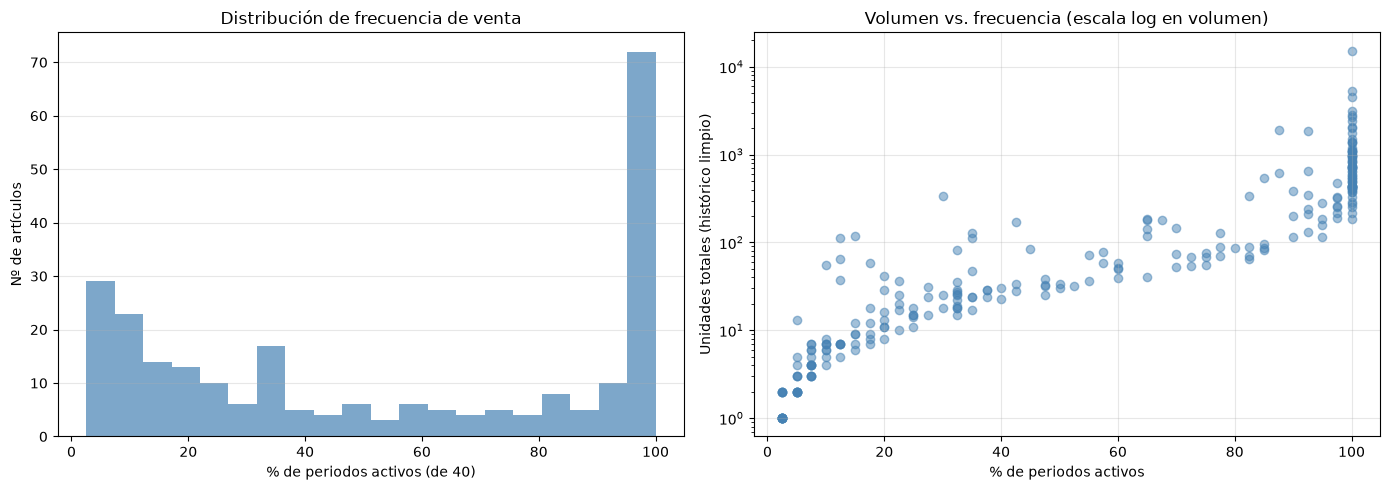

In [18]:
# ── 5.2 Distribución de ambas métricas, para decidir el umbral con datos ────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(ranking['pct_periodos_activos'], bins=20, color='steelblue', alpha=0.7)
axes[0].set_xlabel('% de periodos activos (de 40)')
axes[0].set_ylabel('Nº de artículos')
axes[0].set_title('Distribución de frecuencia de venta')
axes[0].grid(axis='y', alpha=0.3)

axes[1].scatter(ranking['pct_periodos_activos'], ranking['total_units'], alpha=0.5, color='steelblue')
axes[1].set_xlabel('% de periodos activos')
axes[1].set_ylabel('Unidades totales (histórico limpio)')
axes[1].set_yscale('log')
axes[1].set_title('Volumen vs. frecuencia (escala log en volumen)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ranking_articulos_volumen_frecuencia.png', dpi=150, bbox_inches='tight')
plt.show()

**El histograma es bimodal — hay una separación natural, pero no es limpia**

Se ve claramente una masa grande cerca del 100% (artículos de carta "core", siempre disponibles y pedidos) y otra masa relevante por debajo del 20% (cola larga de intermitencia real, que ya validamos en la sección 4 que es genuina, no artefacto). El tramo intermedio (20-80%) está mucho más disperso y con menos artículos — no hay un "punto de corte" que salte a la vista solo mirando la forma, hace falta ver el conteo exacto en un par de candidatos a umbral antes de fijar uno.

**El scatter confirma la relación esperada, con RACIÓN DE PAN claramente fuera de la nube**

A mayor frecuencia, mayor volumen (lógico), con dispersión de hasta 2 órdenes de magnitud en el mismo nivel de frecuencia — eso es justo lo que capturan total_units y pct_periodos_activos como métricas independientes, tal como las planteamos. El punto en la esquina superior derecha, claramente por encima de la nube del resto de artículos al 100%, es RACIÓN DE PAN — visualmente confirma que no es solo el más vendido, es cualitativamente distinto al resto.

In [19]:
# ── 5.3 Cuantiles de referencia, para proponer un umbral razonado ───────────
print("Cuantiles de % de periodos activos:")
display(ranking['pct_periodos_activos'].describe(percentiles=[.25, .5, .75, .9]))

print("\nCuantiles de volumen total:")
display(ranking['total_units'].describe(percentiles=[.25, .5, .75, .9]))

Cuantiles de % de periodos activos:


count    249.000000
mean      53.825301
std       38.529558
min        2.500000
25%       15.000000
50%       47.500000
75%      100.000000
90%      100.000000
max      100.000000
Name: pct_periodos_activos, dtype: float64


Cuantiles de volumen total:


count      249.000000
mean       385.373494
std       1149.740585
min          1.000000
25%          9.000000
50%         55.000000
75%        396.000000
90%        958.600000
max      15227.000000
Name: total_units, dtype: float64

**MENU DEL DIA (30001) — aclara qué es antes de considerarlo candidato**

department_name = MENU DEL DIA igual que article_name — probablemente es un paquete/menú cerrado, no un plato individual. Si es así, predecirlo es un problema distinto (cuántos menús se venden, no qué composición tienen) y no encaja como ejemplo de "predicción de un artículo" sin explicarlo aparte. Antes de incluirlo, comprueba en df_menu o df_articulos si tiene una naturaleza distinta al resto de códigos.

In [20]:
# ── Investigación de MENU DEL DIA (30001) ─────────────

# Reconstruimos comensales_por_periodo aquí para no depender de que la celda
# de la Sección 5.4 original se haya ejecutado antes en esta sesión.
comensales_por_periodo = []
for _, row in periodos_prep.iterrows():
    mask = (tabla_maestra['fecha'] >= row['report_start']) & (tabla_maestra['fecha'] <= row['report_end'])
    comensales_por_periodo.append({
        'report_start': row['report_start'],
        'comensales_totales': tabla_maestra.loc[mask, 'comensales_completada'].sum()
    })
comensales_por_periodo = pd.DataFrame(comensales_por_periodo)

# 1. ¿Qué dice el catálogo sobre él?
print("En df_articulos:")
display(df_articulos[df_articulos['article_code'] == 30001])

print("\nEn df_menu:")
display(df_menu[df_menu['article_code'] == 30001])

# 2. Estabilidad de su precio unitario
precio_menu_dia = df_ventas_prep[df_ventas_prep['article_code'] == 30001]
print(f"\nPrecio unitario de MENU DEL DIA — media: {precio_menu_dia['precio_unitario'].mean():.2f}, "
      f"std: {precio_menu_dia['precio_unitario'].std():.2f}, "
      f"min: {precio_menu_dia['precio_unitario'].min():.2f}, "
      f"max: {precio_menu_dia['precio_unitario'].max():.2f}")

# 3. Correlación con comensales
serie_menu = (
    df_ventas_prep[df_ventas_prep['article_code'] == 30001]
    .merge(comensales_por_periodo, on='report_start', how='left')
)
corr_menu = serie_menu['units'].corr(serie_menu['comensales_totales'])
print(f"\nCorrelación de MENU DEL DIA con comensales: {corr_menu:.3f}")

En df_articulos:


,source_file,article_code,article_name,department_code
252,ARTICULOS.xls,30001,MENU DEL DIA,30



En df_menu:


,source_file,article_code,article_name
252,CARTA.xls,30001,MENU DEL DIA



Precio unitario de MENU DEL DIA — media: 18.34, std: 0.43, min: 17.70, max: 19.00

Correlación de MENU DEL DIA con comensales: 0.102


In [21]:
# ── 5.4 Correlación con comensales — TODOS los artículos, no solo los sospechosos ──
MIN_PERIODOS_PARA_CORRELACION = 5  # por debajo de esto, el coeficiente no es fiable

correlaciones_aforo = []
for codigo in ranking['article_code']:
    serie_articulo = (
        df_ventas_ranking[df_ventas_ranking['article_code'] == codigo]
        .merge(comensales_por_periodo, on='report_start', how='left')
    )
    nombre = serie_articulo['article_name'].iloc[0]
    n_puntos = len(serie_articulo)

    # La condición que faltaba: solo calculamos corr si hay suficientes puntos
    # Y si units tiene varianza (si siempre vende lo mismo, std=0 y corr es NaN o indefinida)
    if n_puntos >= MIN_PERIODOS_PARA_CORRELACION and serie_articulo['units'].std() > 0:
        corr = serie_articulo['units'].corr(serie_articulo['comensales_totales'])
    else:
        corr = np.nan

    correlaciones_aforo.append({
        'article_code': codigo,
        'article_name': nombre,
        'n_periodos_activos': n_puntos,
        'corr_comensales': round(corr, 3) if pd.notna(corr) else np.nan
    })

correlaciones_aforo = pd.DataFrame(correlaciones_aforo).sort_values('corr_comensales', ascending=False)
print(f"Artículos con correlación calculada (>= {MIN_PERIODOS_PARA_CORRELACION} periodos activos): "
      f"{correlaciones_aforo['corr_comensales'].notna().sum()} de {len(correlaciones_aforo)}")
display(correlaciones_aforo.head(20))

Artículos con correlación calculada (>= 5 periodos activos): 193 de 249


,article_code,article_name,n_periodos_activos,corr_comensales
0,96,RACIÓN DE PAN,40,0.882
5,2309,AGUA 70CL,40,0.772
2,1690,CAFÉ E INFUSIONES,40,0.688
143,2306,PAN BAO DE COCHINITA PIBIL,11,0.600
34,2298,PLUMA DE BELLOTA A LA BRASA,40,0.594
30,2060,PATATAS FRITAS GAJO,40,0.568
29,1939,ALCACHOFA A LA BRASA,40,0.566
77,1964,COSTILLA DE VACA ANGUS,40,0.552
75,2143,"FIDEUA ""AL HORNO"" DE BOTILLO",39,0.530
19,1801,TARTA ARABE,40,0.529


In [22]:
print("Distribución de corr_comensales (solo artículos con n >= 5 periodos):")
display(correlaciones_aforo['corr_comensales'].describe(percentiles=[.25, .5, .75, .9]))

Distribución de corr_comensales (solo artículos con n >= 5 periodos):


count    193.000000
mean       0.125508
std        0.300580
min       -0.836000
25%       -0.036000
50%        0.159000
75%        0.327000
90%        0.481000
max        0.882000
Name: corr_comensales, dtype: float64

#### Correlación con comensales — artículos con alta frecuencia de venta

Antes de incluir un artículo en la shortlist de candidatos, comprobamos si su demanda
sigue realmente dinámicas propias (clima, festivos, eventos) o si es, en la práctica,
un **proxy del aforo** (número de comensales), en cuyo caso "predecirlo" no demostraría
nada sobre el objetivo real del proyecto.

Sobre 193 artículos con suficientes periodos activos (≥5) para calcular una correlación
fiable, la mediana es 0.159 y el percentil 90 es 0.481 — es decir, cierta correlación
positiva con el aforo es el comportamiento normal del catálogo (días con más comensales
venden más de casi todo), no una anomalía. Solo se trata como proxy de aforo lo que
queda muy por encima incluso de ese percentil 90:

| Artículo | Correlación con comensales | Lectura |
|---|---|---|
| RACIÓN DE PAN | 0.882 | **Proxy de aforo** — descartado como candidato |
| AGUA 70CL | 0.772 | **Proxy de aforo** — descartado como candidato |
| CAFÉ E INFUSIONES | 0.688 | Zona gris — **se mantiene como candidato válido**, con la salvedad anotada en el informe |
| COCA COLA ZERO | 0.412 | Elección real de cliente — candidato válido |
| AGUA CON GAS | 0.335 | Elección real de cliente — candidato válido |
| AGUA CRISTAL | 0.221 | Elección real de cliente — candidato válido |

**El resto del top 20 por correlación (PLUMA DE BELLOTA, PATATAS FRITAS GAJO, ALCACHOFA
A LA BRASA, COSTILLA DE VACA ANGUS, TARTA ARABE, CHULETÓN DE VACA VIEJA, YEMA DE HUEVO DE
CORRAL, y similares, en el rango 0.49–0.60) no se excluye.** Su correlación está por
encima de la mediana del catálogo pero es coherente con ser platos populares que también
se benefician de días de más aforo — es la señal de demanda esperada, no un artefacto de
servicio automático.

**Nota:** que AGUA CRISTAL (0.221) y AGUA 70CL (0.772) tengan correlaciones tan
distintas sugiere que no son la misma agua servida de dos formas — probablemente
una es de cortesía/mesa (sigue al aforo) y la otra una marca embotellada de
elección del cliente. Pendiente de confirmar en `df_menu`/`df_articulos` (categoría
o precio), aunque no es bloqueante para fijar el umbral de la Sección 5.

In [23]:
# ── 5.5 Conteo exacto de artículos por umbral candidato ──────────────────────
for umbral in [50, 60, 70, 80, 90, 95]:
    n = (ranking['pct_periodos_activos'] >= umbral).sum()
    print(f"Artículos con >= {umbral}% de periodos activos: {n}")

Artículos con >= 50% de periodos activos: 124
Artículos con >= 60% de periodos activos: 117
Artículos con >= 70% de periodos activos: 107
Artículos con >= 80% de periodos activos: 96
Artículos con >= 90% de periodos activos: 85
Artículos con >= 95% de periodos activos: 76


In [24]:
UMBRAL_FRECUENCIA = 90

candidatos_finales = ranking[
    (ranking['pct_periodos_activos'] >= UMBRAL_FRECUENCIA) &
    (~ranking['article_code'].isin([96, 2309, 30001]))  # proxy de aforo + paquete cerrado
].sort_values('total_units', ascending=False).reset_index(drop=True)

print(f"Candidatos finales tras todos los filtros: {len(candidatos_finales)}")
display(candidatos_finales.head(20))

Candidatos finales tras todos los filtros: 82


,article_code,total_units,n_periodos_activos,pct_periodos_activos,unidades_medias_periodo_activo,article_name,department_name
0,1637,5260.0,40,100.0,131.50,COPA DE VICTORIA,CERVEZAS
1,1690,4551.0,40,100.0,113.78,CAFÉ E INFUSIONES,POSTRES
2,2138,3110.0,40,100.0,77.75,SAM DE GAMBAS,CLASICOS
3,1945,2792.0,40,100.0,69.80,EXTRA CROQUETA DE JAMON,EXTRAS
4,2,2443.0,40,100.0,61.08,RAVIOLI DE RABO DE TERNERA,CLASICOS
5,1691,2038.0,40,100.0,50.95,CERVEZA VICTORIA,CERVEZAS
6,2381,2032.0,40,100.0,50.80,PAN BAO DE CARRILLERA DE CERDO,TAPAS CALIENTES
7,48,1756.0,40,100.0,43.90,AGUA CRISTAL,REFRESCOS
8,2280,1508.0,40,100.0,37.70,LEGARIS ROBLE,TINTOS
9,49,1403.0,40,100.0,35.08,AGUA CON GAS,REFRESCOS


In [25]:
# ── Cobertura de facturación y unidades, criterio 90% vs. criterio del compañero ──

total_amount_global = df_ventas_ranking['amount'].sum()
total_units_global = df_ventas_ranking['units'].sum()

# Vuestro criterio (90% periodos + exclusiones ya acordadas)
amount_90 = df_ventas_ranking[df_ventas_ranking['article_code'].isin(candidatos_finales['article_code'])]['amount'].sum()
units_90 = df_ventas_ranking[df_ventas_ranking['article_code'].isin(candidatos_finales['article_code'])]['units'].sum()

print(f"Criterio 90% de periodos (n={len(candidatos_finales)} artículos):")
print(f"  % facturación cubierta: {amount_90 / total_amount_global * 100:.1f}%")
print(f"  % unidades cubiertas  : {units_90 / total_units_global * 100:.1f}%")

# Criterio del compañero: >=8 periodos Y >=20 unidades totales, mismas exclusiones
CODIGOS_EXCLUIDOS = [96, 2309, 30001]  # proxy de aforo + paquete cerrado

candidatos_companero = ranking[
    (ranking['n_periodos_activos'] >= 8) &
    (ranking['total_units'] >= 20) &
    (~ranking['article_code'].isin(CODIGOS_EXCLUIDOS))
].sort_values('total_units', ascending=False).reset_index(drop=True)

amount_comp = df_ventas_ranking[df_ventas_ranking['article_code'].isin(candidatos_companero['article_code'])]['amount'].sum()
units_comp = df_ventas_ranking[df_ventas_ranking['article_code'].isin(candidatos_companero['article_code'])]['units'].sum()

print(f"\nCriterio compañero: >=8 periodos y >=20 unidades (n={len(candidatos_companero)} artículos):")
print(f"  % facturación cubierta: {amount_comp / total_amount_global * 100:.1f}%")
print(f"  % unidades cubiertas  : {units_comp / total_units_global * 100:.1f}%")

# Solapamiento entre ambos conjuntos — para saber si son "el mismo grupo más grande"
# o conjuntos genuinamente distintos
codigos_90 = set(candidatos_finales['article_code'])
codigos_comp = set(candidatos_companero['article_code'])

print(f"\nEn ambos conjuntos: {len(codigos_90 & codigos_comp)}")
print(f"Solo en el vuestro (90%): {len(codigos_90 - codigos_comp)}")
print(f"Solo en el del compañero: {len(codigos_comp - codigos_90)}")

Criterio 90% de periodos (n=82 artículos):
  % facturación cubierta: 75.4%
  % unidades cubiertas  : 70.0%

Criterio compañero: >=8 periodos y >=20 unidades (n=155 artículos):
  % facturación cubierta: 86.8%
  % unidades cubiertas  : 78.3%

En ambos conjuntos: 82
Solo en el vuestro (90%): 0
Solo en el del compañero: 73


Con un criterio estricto de calidad de serie (90% de presencia) cubrimos el 75.4% de la facturación con 82 artículos; relajando el criterio a demanda mínima viable (≥8 periodos, ≥20 unidades) la cobertura sube a 86.8% con 155 artículos, aunque muchos de estos últimos tienen series demasiado intermitentes para el enfoque de regresión propuesto aquí.

### 6. Selección del alcance a modelar

Con los 82 candidatos que superan el filtro de la Sección 5 (≥90% de periodos activos,
excluidos proxies de aforo y no-productos), queda por decidir cuántos artículos se modelan
y con qué arquitectura. Se plantean tres rutas:

- **A. Un solo artículo** — pipeline más simple, fácil de explicar, pero no demuestra que
  el enfoque escale al resto del catálogo.
- **B. Varios artículos, un modelo por artículo** — muestra que "funciona en más de un caso",
  pero extrapolar de N modelos individuales a los 82 (o a los 251 totales) es una afirmación,
  no algo que el propio proceso demuestre.
- **C. Modelo panel** — un único modelo entrenado sobre los 82 artículos a la vez, con
  `article_code` como variable. Es la única ruta que demuestra generalización real al
  catálogo con el mismo pipeline, en vez de simularla repitiendo el proceso a mano.

Se opta por la **ruta C**.

In [26]:
# ── 6.1 Confirmación del conjunto final de candidatos para el modelo panel ──

print(f"Artículos en el modelo panel: {len(candidatos_finales)}")
print(f"Periodos por artículo: {n_periodos_totales}")
print(f"Tamaño esperado del panel (antes de reindexar huecos): "
      f"{len(candidatos_finales)} artículos x {n_periodos_totales} periodos = "
      f"{len(candidatos_finales) * n_periodos_totales} filas")

print(f"\nDistribución por departamento:")
display(candidatos_finales['department_name'].value_counts())

print(f"\nTop 10 por volumen (referencia rápida):")
display(candidatos_finales[['article_code', 'article_name', 'department_name', 'total_units', 'pct_periodos_activos']].head(10))

Artículos en el modelo panel: 82
Periodos por artículo: 40
Tamaño esperado del panel (antes de reindexar huecos): 82 artículos x 40 periodos = 3280 filas

Distribución por departamento:


department_name
CARTA              16
CERVEZAS            9
POSTRES             8
TAPAS CALIENTES     8
REFRESCOS           8
TAPAS FRIAS         7
CLASICOS            6
SUGERENCIAS         5
EXTRAS              4
TINTOS              3
BLANCOS             3
GUARNICIONES        3
LICORES             2
Name: count, dtype: int64


Top 10 por volumen (referencia rápida):


,article_code,article_name,department_name,total_units,pct_periodos_activos
0,1637,COPA DE VICTORIA,CERVEZAS,5260.0,100.0
1,1690,CAFÉ E INFUSIONES,POSTRES,4551.0,100.0
2,2138,SAM DE GAMBAS,CLASICOS,3110.0,100.0
3,1945,EXTRA CROQUETA DE JAMON,EXTRAS,2792.0,100.0
4,2,RAVIOLI DE RABO DE TERNERA,CLASICOS,2443.0,100.0
5,1691,CERVEZA VICTORIA,CERVEZAS,2038.0,100.0
6,2381,PAN BAO DE CARRILLERA DE CERDO,TAPAS CALIENTES,2032.0,100.0
7,48,AGUA CRISTAL,REFRESCOS,1756.0,100.0
8,2280,LEGARIS ROBLE,TINTOS,1508.0,100.0
9,49,AGUA CON GAS,REFRESCOS,1403.0,100.0


**Decisión: modelo panel con los 82 artículos candidatos**, entrenado sobre el producto
cartesiano artículo × periodo (82 × 40 = 3.280 filas antes de aplicar el zero-fill de huecos).
`article_code` se incorpora como variable categórica del modelo, permitiendo que las 82 series
compartan patrones de estacionalidad, festivos y clima (pooling estadístico) en vez de
aprenderlos cada una de forma aislada con solo 40 puntos propios.

**Justificación frente a las alternativas**: un modelo panel demuestra que el pipeline
generaliza al catálogo con el mismo proceso, en vez de requerir un ajuste manual por artículo
(ruta B) o dejar la escalabilidad como una afirmación no verificada (ruta A). Es la opción más
costosa de construir correctamente — exige cuidado especial en agrupar por `article_code` antes
de calcular lags o rolling windows (Sección 12) y en separar variación *within*/*between* al
interpretar correlaciones (Sección 11) — pero es la más defendible en una evaluación técnica.

**Consecuencia para el resto del notebook**: las Secciones 7 en adelante se construyen para
82 artículos simultáneamente, no para uno. El reindexado de huecos (Sección 7), el join con
la tabla maestra (Sección 9) y la evaluación (Sección 15) deben operar a nivel de panel, no
como si se repitiera 82 veces el proceso pensado originalmente para un único artículo.

### 7. Construcción de la espina completa (reindexado)

`df_ventas_ranking` solo contiene filas con venta real — para los 82 artículos candidatos,
un periodo sin fila significa 0 unidades vendidas (supuesto ya validado en la Sección 4).
Para que el modelo panel funcione correctamente (lags, rolling windows, target sin huecos),
necesitamos la espina completa: **82 artículos × 40 periodos = 3.280 filas**, con ceros
explícitos donde no hubo venta, no filas ausentes.

Tres decisiones de esta sección merecen explicarse antes del código, porque no son obvias:

- **Metadata estable** (`article_name`, `department_name_final`, `department_code_final`) se
  trae una vez por artículo, no se repite el join complejo de la Sección 3.
- **`precio_unitario`** en las filas sin venta no se rellena con 0 — un precio de 0 significa
  "gratis", no "no hubo venta". Se deja como `NaN` explícito.
- **`es_sugerencia_del_periodo`** es la más delicada: para una fila sin venta no sabemos
  directamente si ese periodo el artículo estaba clasificado como sugerencia o como carta.
  Se infiere por proximidad temporal dentro del mismo artículo (el cambio de estado ocurre en
  un punto concreto del calendario, no de forma aleatoria) — no se puede rellenar con un
  valor fijo sin más.

In [27]:
# ── 7.1 Catálogo de metadata estable por artículo candidato ─────────────────

dept_code_final_por_articulo = (
    df_ventas_ranking.groupby('article_code')['department_code_final']
    .first()
    .reset_index()
)

catalogo_candidatos = (
    candidatos_finales[['article_code', 'article_name', 'department_name']]
    .rename(columns={'department_name': 'department_name_final'})
    .merge(dept_code_final_por_articulo, on='article_code', how='left')
)

print(f"Artículos en el catálogo: {len(catalogo_candidatos)}")

Artículos en el catálogo: 82


In [28]:
# ── 7.2 Espina de periodos con duración (para normalizar después) ───────────

espina_periodos = periodos_prep.copy()
espina_periodos['duracion_periodo'] = (
    (espina_periodos['report_end'] - espina_periodos['report_start']).dt.days + 1
)

print(f"Periodos en la espina: {len(espina_periodos)}")

Periodos en la espina: 40


In [29]:
# ── 7.3 Producto cartesiano: cada artículo x cada periodo ───────────────────

espina_completa = catalogo_candidatos.merge(espina_periodos, how='cross')
print(f"Filas en la espina completa: {len(espina_completa)} "
      f"({len(catalogo_candidatos)} artículos x {len(espina_periodos)} periodos, "
      f"esperado: {len(catalogo_candidatos) * len(espina_periodos)})")

Filas en la espina completa: 3280 (82 artículos x 40 periodos, esperado: 3280)


In [30]:
# ── 7.4 Join con los datos reales de venta ───────────────────────────────────

datos_reales = df_ventas_ranking[
    df_ventas_ranking['article_code'].isin(candidatos_finales['article_code'])
][['article_code', 'report_start', 'units', 'amount', 'precio_unitario', 'sugerencias']]

# Comprobación: no debería haber más de una fila por artículo+periodo
n_duplicados = datos_reales.duplicated(subset=['article_code', 'report_start']).sum()
if n_duplicados > 0:
    print(f"⚠️  {n_duplicados} combinaciones artículo+periodo duplicadas — revisar antes de continuar")

panel = espina_completa.merge(datos_reales, on=['article_code', 'report_start'], how='left')

n_con_venta = panel['units'].notna().sum()
n_sin_venta = panel['units'].isna().sum()
print(f"\nFilas con venta real: {n_con_venta}")
print(f"Filas sin venta (a rellenar con 0): {n_sin_venta}")
print(f"Total: {n_con_venta + n_sin_venta} (esperado: {len(panel)})")



Filas con venta real: 3238
Filas sin venta (a rellenar con 0): 42
Total: 3280 (esperado: 3280)


In [31]:
# ── 7.5 Zero-fill y normalización ────────────────────────────────────────────

panel['units'] = panel['units'].fillna(0)
panel['amount'] = panel['amount'].fillna(0)
# precio_unitario se deja como NaN en filas sin venta — no existe un precio real que asignar

panel = panel.sort_values(['article_code', 'report_start']).reset_index(drop=True)

# sugerencias: inferido por proximidad temporal dentro de cada artículo
panel['sugerencias'] = (
    panel.groupby('article_code')['sugerencias']
    .transform(lambda s: s.ffill().bfill())
    .astype(int)
)

panel['units_por_dia'] = panel['units'] / panel['duracion_periodo']

print(f"\nPanel final: {panel.shape[0]} filas x {panel.shape[1]} columnas")
display(panel.head(10))


Panel final: 3280 filas x 12 columnas


,article_code,article_name,department_name_final,department_code_final,report_start,report_end,duracion_periodo,units,amount,precio_unitario,sugerencias,units_por_dia
0,1,NUESTRAS CROQUETAS DE JAMON,CLASICOS,28,2025-10-01,2025-10-05,5,28.0,151.63644,5.415587,0,5.600000
1,1,NUESTRAS CROQUETAS DE JAMON,CLASICOS,28,2025-10-06,2025-10-12,7,32.0,198.18195,6.193186,0,4.571429
2,1,NUESTRAS CROQUETAS DE JAMON,CLASICOS,28,2025-10-13,2025-10-19,7,20.0,112.18190,5.609095,0,2.857143
3,1,NUESTRAS CROQUETAS DE JAMON,CLASICOS,28,2025-10-20,2025-10-26,7,28.0,155.81828,5.564939,0,4.000000
4,1,NUESTRAS CROQUETAS DE JAMON,CLASICOS,28,2025-10-27,2025-11-02,7,18.0,107.63643,5.979802,0,2.571429
5,1,NUESTRAS CROQUETAS DE JAMON,CLASICOS,28,2025-11-03,2025-11-09,7,24.0,145.09101,6.045459,0,3.428571
6,1,NUESTRAS CROQUETAS DE JAMON,CLASICOS,28,2025-11-10,2025-11-16,7,26.0,156.00007,6.000003,0,3.714286
7,1,NUESTRAS CROQUETAS DE JAMON,CLASICOS,28,2025-11-17,2025-11-23,7,28.0,195.27281,6.974029,0,4.000000
8,1,NUESTRAS CROQUETAS DE JAMON,CLASICOS,28,2025-11-24,2025-11-30,7,23.0,153.81825,6.687750,0,3.285714
9,1,NUESTRAS CROQUETAS DE JAMON,CLASICOS,28,2025-12-01,2025-12-07,7,28.0,181.09097,6.467535,0,4.000000


In [32]:
# ── 7.6 Verificaciones de integridad ─────────────────────────────────────────

print(f"\n¿Algún artículo con menos de 40 filas en el panel?: "
      f"{(panel.groupby('article_code').size() != 40).any()}")
print(f"¿Algún NaN en sugerencias tras ffill/bfill?: "
      f"{panel['sugerencias'].isna().any()}")
print(f"¿Algún NaN en units_por_dia?: {panel['units_por_dia'].isna().any()}")


¿Algún artículo con menos de 40 filas en el panel?: False
¿Algún NaN en sugerencias tras ffill/bfill?: False
¿Algún NaN en units_por_dia?: False


#### Conclusiones

Se construye el panel completo mediante producto cartesiano de los 82 artículos candidatos
por los 40 periodos limpios (3.280 filas), uniendo después los datos reales de venta.

- **3.238 filas (98.7%) tienen venta real; 42 filas (1.3%) se rellenan con cero** — coherente
  con el filtro de ≥90% de periodos activos aplicado en la Sección 5 (máximo 4 huecos posibles
  por artículo de los 82). No aparecen huecos por encima de lo esperado, lo que confirma que
  el filtro de calidad de serie funcionó como se pretendía.
- `precio_unitario` se deja como `NaN` explícito en las filas sin venta (un precio de 0
  significaría "gratis", no "sin venta ese periodo").
- `sugerencias` se infiere por proximidad temporal (`ffill`/`bfill`) dentro de cada artículo,
  ya que el cambio de estado Sugerencias↔Carta ocurre en un punto concreto del calendario, no
  de forma aleatoria entre periodos.
- Verificación de integridad: todos los artículos tienen exactamente 40 filas en el panel, y
  no queda ningún valor nulo en `sugerencias` ni en `units_por_dia` — la espina queda cerrada
  sin cabos sueltos antes de construir el target y las features exógenas.

**Panel resultante**: 3.280 filas x 12 columnas.

### 8. Target final

`units_por_dia` ya quedó calculada en la Sección 7 dentro de la construcción del panel —
esta sección no la recalcula, la **formaliza como target** y comprueba tres cosas propias
de un target en formato panel que todavía no se han mirado:

- **Inflación de ceros**: con el zero-fill de la Sección 7, ahora hay ceros "reales" (el
  artículo existía y no se vendió ese periodo) mezclados con la venta real. Hay que medir
  cuántos son, en conjunto y por artículo, porque un target con demasiados ceros condiciona
  qué familia de modelos tiene sentido usar más adelante.
- **Heterogeneidad de escala entre artículos**: los 82 candidatos no venden ni de lejos lo
  mismo entre sí (de justo por encima del umbral de la Sección 5 hasta los más vendidos).
  Esto importa para el modelo panel: una misma unidad de error absoluto pesa muy distinto
  según el artículo, y hay que decidirlo con datos, no asumirlo.
- **Qué columna es "el target"**: se fija `units_por_dia` como target de modelado, y se
  conservan `units` + `duracion_periodo` para poder reconstruir el total del periodo original
  al reportar resultados (el negocio piensa en unidades por semana, no en tasas diarias).

In [33]:
# ── 8.1 Inflación de ceros: global y por artículo ────────────────────────────

pct_ceros_global = (panel['units'] == 0).mean() * 100
print(f"% de filas con units=0 en el panel: {pct_ceros_global:.1f}%")

ceros_por_articulo = (
    panel.groupby('article_code')
    .apply(lambda g: (g['units'] == 0).mean() * 100, include_groups=False)
    .rename('pct_ceros')
    .sort_values(ascending=False)
)

print(f"\nArtículos con más ceros (recordatorio: máximo posible es 10%, por el filtro de la Sección 5):")
display(ceros_por_articulo.head(10))

% de filas con units=0 en el panel: 1.3%

Artículos con más ceros (recordatorio: máximo posible es 10%, por el filtro de la Sección 5):


article_code
2245    10.0
2046    10.0
2325    10.0
1944     7.5
2239     7.5
2160     7.5
82       7.5
1971     7.5
1739     5.0
1740     5.0
Name: pct_ceros, dtype: float64

In [34]:
# ── 8.2 Heterogeneidad de escala entre los 82 artículos ─────────────────────

resumen_escala = (
    panel.groupby('article_code')['units_por_dia']
    .agg(['mean', 'std', 'min', 'max'])
    .rename(columns={'mean': 'media', 'std': 'desviacion', 'min': 'minimo', 'max': 'maximo'})
)
resumen_escala['cv'] = (resumen_escala['desviacion'] / resumen_escala['media']).round(2)

print(f"Rango de medias entre artículos: {resumen_escala['media'].min():.2f} a {resumen_escala['media'].max():.2f} unidades/día")
print(f"Ratio entre el más vendido y el menos vendido: {resumen_escala['media'].max() / resumen_escala['media'].min():.1f}x")

print(f"\nDistribución del coeficiente de variación (variabilidad interna de cada artículo):")
display(resumen_escala['cv'].describe())

Rango de medias entre artículos: 0.42 a 18.99 unidades/día
Ratio entre el más vendido y el menos vendido: 45.7x

Distribución del coeficiente de variación (variabilidad interna de cada artículo):


count    82.000000
mean      0.437073
std       0.155544
min       0.180000
25%       0.310000
50%       0.390000
75%       0.535000
max       0.870000
Name: cv, dtype: float64

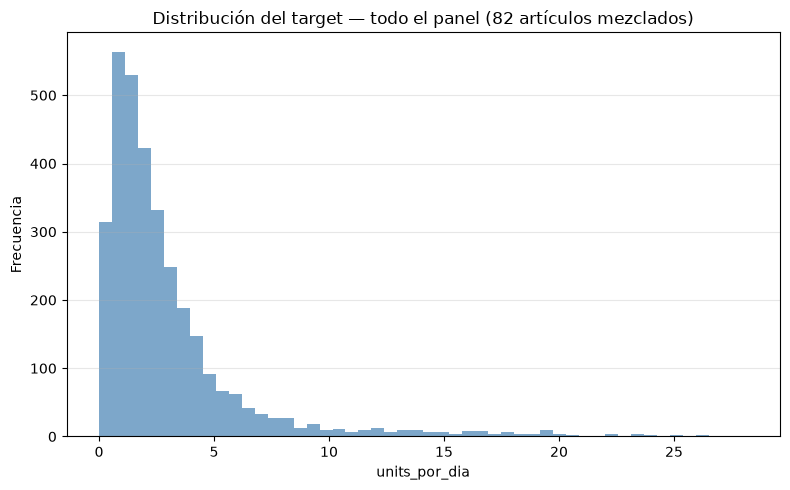

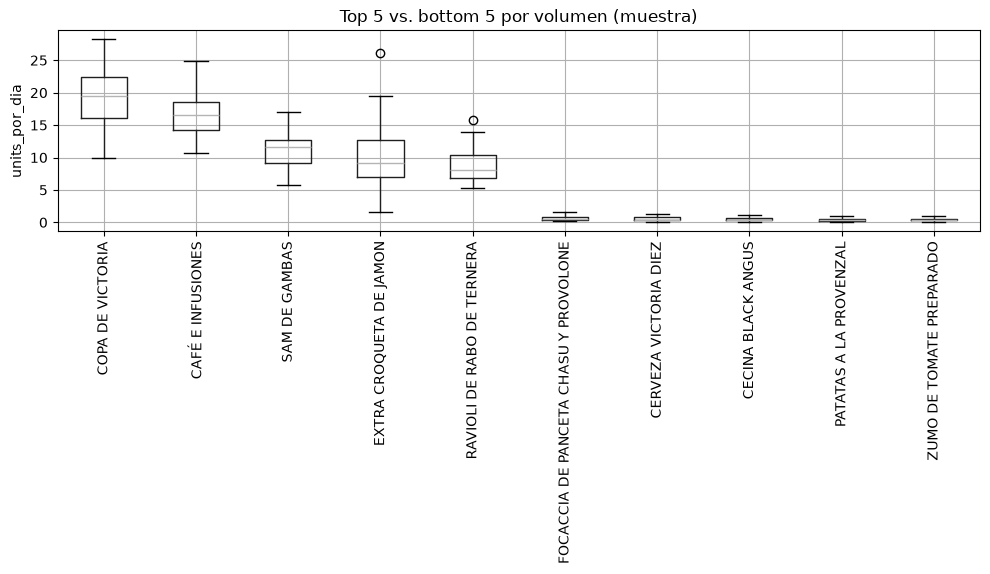

In [35]:
# ── 8.3a Distribución del target — panel completo ────────────────────────────

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(panel['units_por_dia'], bins=50, color='steelblue', alpha=0.7)
ax.set_xlabel('units_por_dia')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución del target — todo el panel (82 artículos mezclados)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'target_distribucion_global.png', dpi=150, bbox_inches='tight')
plt.show()


# ── 8.3b Top 5 vs. bottom 5 por volumen ──────────────────────────────────────

muestra_codigos = list(resumen_escala.sort_values('media', ascending=False).head(5).index) + \
                   list(resumen_escala.sort_values('media', ascending=False).tail(5).index)

datos_muestra = panel[panel['article_code'].isin(muestra_codigos)].copy()

# Ordenamos las categorías del boxplot por volumen medio, de mayor a menor,
# para que se lea igual que la lógica del propio filtro (top primero)
orden_nombres = (
    datos_muestra.groupby('article_name')['units_por_dia']
    .mean().sort_values(ascending=False).index.tolist()
)
datos_muestra['article_name'] = pd.Categorical(
    datos_muestra['article_name'], categories=orden_nombres, ordered=True
)

fig, ax = plt.subplots(figsize=(10, 6))
datos_muestra.boxplot(column='units_por_dia', by='article_name', ax=ax, rot=90)
ax.set_title('Top 5 vs. bottom 5 por volumen (muestra)')
ax.set_xlabel('')
ax.set_ylabel('units_por_dia')
plt.suptitle('')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'target_top_bottom_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

#### Conclusiones

**Inflación de ceros**: 1.3% de las 3.280 filas del panel tienen `units=0` — coherente con
lo ya adelantado en la Sección 7. Los artículos con más ceros (`2245`, `2046`, `2325` con 10%,
el máximo posible dado el filtro de la Sección 5) no destacan por ningún otro motivo aparente;
no hay indicios de que el zero-fill esté introduciendo un sesgo sistemático. El nivel de
ceros es bajo — un target con esta proporción no requiere técnicas específicas de demanda
intermitente (tipo Croston) a nivel de panel; cualquier problema de intermitencia real quedó
ya filtrado en la Sección 5.

**Heterogeneidad de escala entre artículos**: las medias van de 0.42 a 18.99 unidades/día,
un ratio de **45.7x** entre el artículo más y menos vendido de los 82. Es una diferencia de
escala considerable, y tiene una consecuencia práctica directa: el histograma global del
target (Sección 8.3a) está dominado visualmente por los artículos de menor volumen, que son
mayoría — cualquier análisis de correlación o EDA que se haga sobre `units_por_dia` en crudo
(Sección 11) va a estar sesgado hacia ese grupo. **Se aplicará una transformación log1p solo
para fines exploratorios y de correlación**, manteniendo `units_por_dia` sin transformar como
target real del modelo — los resultados finales deben reportarse en unidades reales, que es
lo que tiene sentido operativo para el negocio.

**Variabilidad interna (CV) por artículo**: media 0.44, con recorrido 0.18–0.87. No hay
valores extremos que sugieran un artículo con comportamiento anómalo (un CV cercano a 0
indicaría venta casi constante, sospechoso de proxy de aforo residual; uno muy por encima de 1
indicaría una serie casi tan errática como ruido). El rango observado es el esperable para
demanda de restaurante con influencia de estacionalidad semanal y festivos — no se detecta
ningún caso que amerite exclusión adicional en esta sección.

**Target confirmado**: `units_por_dia`, sin transformar, con `units` y `duracion_periodo`
conservadas para reconstruir el total del periodo al reportar resultados de negocio. El panel
queda listo para la Sección 9 (features exógenas por rango de fechas).

### 9. Features exógenas por periodo

`tabla_maestra_diaria` está a nivel día; el panel está a nivel artículo × periodo (semana).
El join no es un `merge` directo por fecha — es una **agregación por rango**: para cada uno
de los 40 periodos, se resumen los días de `tabla_maestra_diaria` que caen dentro de ese
rango, y el resultado se reparte (broadcast) a los 82 artículos de ese periodo. El cálculo se
hace **una sola vez por periodo**, no 82 veces — el clima o los festivos de una semana son los
mismos para todos los artículos vendidos esa semana.

Dos decisiones antes del código:

- **Se excluyen `facturacion`, `num_tickets`, `ticket_medio` y `ticket_mediano` como features.**
  Son variables agregadas de todo el restaurante que ya incluyen, dentro de su cálculo, la
  contribución de cada uno de los 82 artículos que se están prediciendo — usarlas como
  predictor introduce una fuga de información parcial (más severa cuanto mayor es el peso del
  artículo en la facturación total). El resto de variables (clima, festivos, eventos, reservas)
  son genuinamente externas a la venta de producto y no tienen este problema.
- **Se cuenta explícitamente cuántos días de `tabla_maestra_diaria` caen dentro de cada
  periodo** (`n_dias_matched`). Ya sabíamos que la tabla diaria tiene huecos (39 de 281 días,
  presumiblemente lunes de cierre) — nunca llegamos a confirmarlo del todo (punto pendiente
  del inventario). Aquí se resuelve de forma indirecta: si el patrón de huecos es consistente
  (siempre faltan los mismos días de la semana dentro de cada periodo), las medias/sumas
  agregadas son fiables; si el número de días matched varía de forma irregular entre periodos,
  hay que tenerlo en cuenta antes de confiar en los agregados.

In [36]:
# ── 9.1 Verificación de cobertura: días de tabla_maestra dentro de cada periodo ──

cobertura_periodos = []
for _, row in espina_periodos.iterrows():
    mask = (tabla_maestra['fecha'] >= row['report_start']) & (tabla_maestra['fecha'] <= row['report_end'])
    dias_en_periodo = tabla_maestra.loc[mask]
    cobertura_periodos.append({
        'report_start': row['report_start'],
        'duracion_periodo': row['duracion_periodo'],
        'n_dias_matched': len(dias_en_periodo),
    })

cobertura_periodos = pd.DataFrame(cobertura_periodos)
cobertura_periodos['dias_faltantes'] = cobertura_periodos['duracion_periodo'] - cobertura_periodos['n_dias_matched']

print("Distribución de días faltantes por periodo (duración esperada - días con datos reales):")
display(cobertura_periodos['dias_faltantes'].value_counts().sort_index())

print(f"\nPeriodos con más de 1 día faltante (revisar si el patrón no es 'solo lunes'):")
display(cobertura_periodos[cobertura_periodos['dias_faltantes'] > 1])

print(f"\n¿Algún periodo sin NINGÚN día de datos? (crítico si aparece): "
      f"{(cobertura_periodos['n_dias_matched'] == 0).any()}")

Distribución de días faltantes por periodo (duración esperada - días con datos reales):


dias_faltantes
0     1
1    39
Name: count, dtype: int64


Periodos con más de 1 día faltante (revisar si el patrón no es 'solo lunes'):


,report_start,duracion_periodo,n_dias_matched,dias_faltantes



¿Algún periodo sin NINGÚN día de datos? (crítico si aparece): False


In [37]:
# ── 9.1b Confirmación: ¿el día faltante es siempre el mismo día de la semana? ──

dias_faltantes_detalle = []
for _, row in espina_periodos.iterrows():
    dias_del_periodo = pd.date_range(row['report_start'], row['report_end'], freq='D')
    dias_presentes = tabla_maestra[
        (tabla_maestra['fecha'] >= row['report_start']) & (tabla_maestra['fecha'] <= row['report_end'])
    ]['fecha']
    dias_ausentes = set(dias_del_periodo) - set(dias_presentes)
    for d in dias_ausentes:
        dias_faltantes_detalle.append(d.day_name())

print("Día de la semana de los días ausentes, en todo el histórico:")
display(pd.Series(dias_faltantes_detalle).value_counts())

Día de la semana de los días ausentes, en todo el histórico:


Monday       34
Tuesday       3
Wednesday     2
Name: count, dtype: int64

In [38]:
# ── 9.1c Los 5 días de cierre que no son lunes: ¿coinciden con festivos? ────

dias_no_lunes = []
for _, row in espina_periodos.iterrows():
    dias_del_periodo = pd.date_range(row['report_start'], row['report_end'], freq='D')
    dias_presentes = tabla_maestra[
        (tabla_maestra['fecha'] >= row['report_start']) & (tabla_maestra['fecha'] <= row['report_end'])
    ]['fecha']
    dias_ausentes = set(dias_del_periodo) - set(dias_presentes)
    for d in dias_ausentes:
        if d.day_name() != 'Monday':
            dias_no_lunes.append(d)

print("Fechas de cierre que no caen en lunes:")
for d in sorted(dias_no_lunes):
    print(f"  {d.date()} ({d.day_name()})")

# ¿El lunes de esa misma semana era festivo? (festivos.csv tiene el calendario completo)
festivos_fechas = set(pd.to_datetime(dfs['festivos']['fecha'] if 'fecha' in dfs['festivos'].columns else []))
for d in sorted(dias_no_lunes):
    lunes_semana = d - pd.Timedelta(days=d.weekday())
    es_festivo_lunes = lunes_semana in festivos_fechas
    print(f"  Semana de {d.date()}: lunes {lunes_semana.date()} festivo = {es_festivo_lunes}")

Fechas de cierre que no caen en lunes:
  2025-10-01 (Wednesday)
  2025-10-14 (Tuesday)
  2025-12-09 (Tuesday)
  2026-01-07 (Wednesday)
  2026-06-09 (Tuesday)
  Semana de 2025-10-01: lunes 2025-09-29 festivo = False
  Semana de 2025-10-14: lunes 2025-10-13 festivo = False
  Semana de 2025-12-09: lunes 2025-12-08 festivo = True
  Semana de 2026-01-07: lunes 2026-01-05 festivo = False
  Semana de 2026-06-09: lunes 2026-06-08 festivo = False


In [39]:
# ── 9.2 Agregación de features exógenas por periodo ──────────────────────────

def agregar_periodo(row, tabla):
    mask = (tabla['fecha'] >= row['report_start']) & (tabla['fecha'] <= row['report_end'])
    dias = tabla.loc[mask]
    if len(dias) == 0:
        return pd.Series(dtype='float64')  # se detectaría en la verificación 9.1
    return pd.Series({
        # Calendario
        'mes_periodo':            dias['mes'].mode().iloc[0],
        'n_dias_finde':           dias['es_fin_de_semana'].sum(),
        # Festivos
        'n_dias_festivo':         dias['es_festivo'].sum(),
        # Eventos
        'n_dias_evento':          dias['tiene_evento'].sum(),
        'intensidad_evento_total': dias['intensidad_evento'].sum(),
        # Meteorología
        'temperature_mean_periodo': dias['temperature_mean'].mean(),
        'temperature_max_periodo':  dias['temperature_max'].max(),
        'temperature_min_periodo':  dias['temperature_min'].min(),
        'precipitation_mm_total':   dias['precipitation_mm'].sum(),
        'precipitation_hours_total': dias['precipitation_hours'].sum(),
        'wind_speed_max_periodo':  dias['wind_speed_max'].max(),
        'sunshine_duration_h_total': dias['sunshine_duration_h'].sum(),
        # Reservas
        'n_reservas_total_periodo': dias['n_reservas_total'].sum(),
        'comensales_completada_periodo': dias['comensales_completada'].sum(),
        'tasa_no_show_media':      dias['tasa_no_show'].mean(),
        'tasa_cancelacion_media':  dias['tasa_cancelacion'].mean(),
    })

features_periodo = espina_periodos.apply(lambda row: agregar_periodo(row, tabla_maestra), axis=1)
features_periodo = pd.concat([espina_periodos[['report_start']], features_periodo], axis=1)

print(f"\nFeatures exógenas construidas: {features_periodo.shape[0]} periodos x {features_periodo.shape[1]} columnas")
display(features_periodo.head())


Features exógenas construidas: 40 periodos x 17 columnas


,report_start,mes_periodo,n_dias_finde,n_dias_festivo,n_dias_evento,intensidad_evento_total,temperature_mean_periodo,temperature_max_periodo,temperature_min_periodo,precipitation_mm_total,precipitation_hours_total,wind_speed_max_periodo,sunshine_duration_h_total,n_reservas_total_periodo,comensales_completada_periodo,tasa_no_show_media,tasa_cancelacion_media
0,2025-10-01,10.0,2.0,0.0,0.0,0.0,20.350000,30.0,11.1,0.0,0.0,17.5,45.763494,107.0,284.0,5.535000,5.270000
1,2025-10-06,10.0,2.0,0.0,3.0,6.0,19.233333,27.6,13.0,0.0,0.0,17.2,57.373686,157.0,420.0,2.873333,9.608333
2,2025-10-13,10.0,2.0,0.0,2.0,4.0,17.333333,24.7,9.9,11.0,8.0,15.0,59.263197,109.0,273.0,3.311667,10.720000
3,2025-10-20,10.0,2.0,0.0,0.0,0.0,16.250000,21.7,9.9,3.9,25.0,24.5,52.128892,130.0,371.0,2.356667,6.895000
4,2025-10-27,10.0,2.0,1.0,3.0,6.0,12.583333,18.5,4.4,16.6,19.0,17.1,29.075719,151.0,368.0,2.463333,10.758333


In [40]:
# ── 9.3 Broadcast al panel completo (82 artículos x cada periodo) ───────────

panel = panel.merge(features_periodo, on='report_start', how='left')

n_nan_tras_join = panel[features_periodo.columns.drop('report_start')].isna().any(axis=1).sum()
print(f"\nFilas del panel con algún NaN tras el join de features: {n_nan_tras_join}")
print(f"Panel final: {panel.shape[0]} filas x {panel.shape[1]} columnas")
display(panel.head())


Filas del panel con algún NaN tras el join de features: 0
Panel final: 3280 filas x 28 columnas


,article_code,article_name,department_name_final,department_code_final,report_start,report_end,duracion_periodo,units,amount,precio_unitario,sugerencias,units_por_dia,mes_periodo,n_dias_finde,n_dias_festivo,n_dias_evento,intensidad_evento_total,temperature_mean_periodo,temperature_max_periodo,temperature_min_periodo,precipitation_mm_total,precipitation_hours_total,wind_speed_max_periodo,sunshine_duration_h_total,n_reservas_total_periodo,comensales_completada_periodo,tasa_no_show_media,tasa_cancelacion_media
0,1,NUESTRAS CROQUETAS DE JAMON,CLASICOS,28,2025-10-01,2025-10-05,5,28.0,151.63644,5.415587,0,5.600000,10.0,2.0,0.0,0.0,0.0,20.350000,30.0,11.1,0.0,0.0,17.5,45.763494,107.0,284.0,5.535000,5.270000
1,1,NUESTRAS CROQUETAS DE JAMON,CLASICOS,28,2025-10-06,2025-10-12,7,32.0,198.18195,6.193186,0,4.571429,10.0,2.0,0.0,3.0,6.0,19.233333,27.6,13.0,0.0,0.0,17.2,57.373686,157.0,420.0,2.873333,9.608333
2,1,NUESTRAS CROQUETAS DE JAMON,CLASICOS,28,2025-10-13,2025-10-19,7,20.0,112.18190,5.609095,0,2.857143,10.0,2.0,0.0,2.0,4.0,17.333333,24.7,9.9,11.0,8.0,15.0,59.263197,109.0,273.0,3.311667,10.720000
3,1,NUESTRAS CROQUETAS DE JAMON,CLASICOS,28,2025-10-20,2025-10-26,7,28.0,155.81828,5.564939,0,4.000000,10.0,2.0,0.0,0.0,0.0,16.250000,21.7,9.9,3.9,25.0,24.5,52.128892,130.0,371.0,2.356667,6.895000
4,1,NUESTRAS CROQUETAS DE JAMON,CLASICOS,28,2025-10-27,2025-11-02,7,18.0,107.63643,5.979802,0,2.571429,10.0,2.0,1.0,3.0,6.0,12.583333,18.5,4.4,16.6,19.0,17.1,29.075719,151.0,368.0,2.463333,10.758333


#### Conclusiones

**Cobertura de `tabla_maestra_diaria` dentro de cada periodo**: 39 de 40 periodos tienen
exactamente 1 día sin datos; el periodo restante (el primero, más corto) no tiene ninguno.
Ningún periodo se queda sin cobertura alguna. El día ausente es lunes en 34 de 39 casos (87%)
— confirma que el restaurante cierra habitualmente los lunes, patrón ya intuido en secciones
anteriores a partir de la ausencia sistemática de esa fecha en `df_ventas` original.

Los 5 casos restantes no son lunes (3 martes, 2 miércoles). Uno corresponde al primer día del
histórico completo (arranque de la captura de datos, no un cierre real). Los otros 4 están
dispersos sin un patrón identificable — solo 1 de los 5 coincide con un festivo en el lunes de
esa semana (20%, no significativamente distinto del azar), así que se descarta la hipótesis de
"cierre desplazado por festivo" como explicación general. Quedan sin explicación certera —
posiblemente cierres puntuales por motivos operativos no capturados en ningún dataset
disponible (mantenimiento, evento privado, vacaciones de plantilla). No se investiga más allá,
al no bloquear la construcción de las features: la agregación por rango ya calcula correctamente
sobre los días disponibles de cada periodo, sin necesidad de explicar cada hueco individual.

**Features exógenas construidas**: 17 columnas por periodo (calendario, festivos, eventos,
meteorología, reservas), calculadas una sola vez sobre los 40 periodos y repartidas
(broadcast) a los 82 artículos correspondientes — evitando recalcular el mismo agregado 82
veces. Se excluyen deliberadamente `facturacion`, `num_tickets`, `ticket_medio` y
`ticket_mediano` por riesgo de fuga de información (son agregados que ya incluyen la venta de
los propios artículos que se están prediciendo).

**Panel final**: 3.280 filas x 28 columnas, sin ningún valor nulo tras el join. Combina
identificación del artículo, target (`units`, `units_por_dia`), metadata de departamento,
`sugerencias`, y las 17 features exógenas del periodo.

**Aviso para la Sección 12 (feature engineering)**: `amount` y `precio_unitario` siguen en el
panel como referencia, pero **no deben usarse como predictores** — `amount` es prácticamente
`units × precio`, así que incluirla sería filtrar el target a través de otra columna casi sin
disfraz. Se conservan únicamente para poder reconstruir facturación estimada al reportar
resultados de negocio, no para entrenar el modelo.

### 10. Dataset final (target + features)

El panel construido en la Sección 9 tiene ya todo lo necesario, pero antes de guardarlo en
Gold como tabla propia del modelo hay que dejarlo en un estado que no admita ambigüedad para
quien lo use después (incluido el propio equipo, en la Sección 12):

- **Separar explícitamente columnas de referencia de columnas predictoras.** `amount` y
  `precio_unitario` se quedan en el dataset (son útiles para reportar resultados en euros),
  pero se documentan como *no utilizables* como feature — ya lo advertimos en la Sección 9,
  aquí queda fijado en la propia estructura del fichero, no solo en un comentario.
- **Comprobar duplicados de clave** (`article_code` + `report_start` debe ser única) antes de
  guardar — un duplicado aquí rompería silenciosamente cualquier lag/rolling de la Sección 12.
- **Revisar dtypes** antes de escribir a parquet: columnas categóricas guardadas como `object`
  ocupan más espacio y son más lentas de agrupar que si se tipan como `category`.
- **Guardar como tabla propia en Gold**, no sobrescribir `tabla_maestra_diaria.parquet` — este
  panel es un producto derivado específico de este notebook, no la fuente compartida del
  equipo.

In [41]:
# ── 10.1 Verificación de clave única antes de guardar ────────────────────────

n_duplicados_clave = panel.duplicated(subset=['article_code', 'report_start']).sum()
print(f"Filas duplicadas por (article_code, report_start): {n_duplicados_clave}")
assert n_duplicados_clave == 0, "Hay duplicados de clave — no seguir hasta resolverlo"

Filas duplicadas por (article_code, report_start): 0


In [42]:
# ── 10.2 Columnas: predictoras vs. referencia (no usar como feature) ────────

COLUMNAS_REFERENCIA_NO_FEATURE = ['amount', 'precio_unitario', 'report_end']
COLUMNAS_IDENTIFICACION = ['article_code', 'article_name', 'report_start', 'duracion_periodo']
COLUMNA_TARGET = 'units_por_dia'

columnas_predictoras_candidatas = [
    c for c in panel.columns
    if c not in COLUMNAS_REFERENCIA_NO_FEATURE + COLUMNAS_IDENTIFICACION + [COLUMNA_TARGET, 'units']
]
print(f"Columnas candidatas a predictoras ({len(columnas_predictoras_candidatas)}):")
print(columnas_predictoras_candidatas)

Columnas candidatas a predictoras (19):
['department_name_final', 'department_code_final', 'sugerencias', 'mes_periodo', 'n_dias_finde', 'n_dias_festivo', 'n_dias_evento', 'intensidad_evento_total', 'temperature_mean_periodo', 'temperature_max_periodo', 'temperature_min_periodo', 'precipitation_mm_total', 'precipitation_hours_total', 'wind_speed_max_periodo', 'sunshine_duration_h_total', 'n_reservas_total_periodo', 'comensales_completada_periodo', 'tasa_no_show_media', 'tasa_cancelacion_media']


In [43]:
# ── 10.3 Ajuste de dtypes ────────────────────────────────────────────────────

panel_final = panel.copy()

panel_final['article_code'] = panel_final['article_code'].astype('category')
panel_final['article_name'] = panel_final['article_name'].astype('category')
panel_final['department_name_final'] = panel_final['department_name_final'].astype('category')
panel_final['department_code_final'] = panel_final['department_code_final'].astype('int64')
panel_final['sugerencias'] = panel_final['sugerencias'].astype('int64')

print(f"\nDtypes finales:")
display(panel_final.dtypes)


Dtypes finales:


article_code                           category
article_name                           category
department_name_final                  category
department_code_final                     int64
report_start                     datetime64[us]
report_end                       datetime64[us]
duracion_periodo                          int64
units                                   float64
amount                                  float64
precio_unitario                         float64
sugerencias                               int64
units_por_dia                           float64
mes_periodo                             float64
n_dias_finde                            float64
n_dias_festivo                          float64
n_dias_evento                           float64
intensidad_evento_total                 float64
temperature_mean_periodo                float64
temperature_max_periodo                 float64
temperature_min_periodo                 float64
precipitation_mm_total                  

In [44]:
# ── 10.3b Corrección de dtypes en las features de conteo/categoría ──────────

columnas_enteras = ['mes_periodo', 'n_dias_finde', 'n_dias_festivo', 'n_dias_evento',
                     'intensidad_evento_total', 'n_reservas_total_periodo',
                     'comensales_completada_periodo']

for col in columnas_enteras:
    panel_final[col] = panel_final[col].astype('int64')

panel_final['mes_periodo'] = panel_final['mes_periodo'].astype('category')

print("Dtypes corregidos:")
display(panel_final[columnas_enteras + ['mes_periodo']].dtypes)

Dtypes corregidos:


mes_periodo                      category
n_dias_finde                        int64
n_dias_festivo                      int64
n_dias_evento                       int64
intensidad_evento_total             int64
n_reservas_total_periodo            int64
comensales_completada_periodo       int64
mes_periodo                      category
dtype: object

In [45]:
# ── 10.4 Guardado en Gold ────────────────────────────────────────────────────

ruta_panel = GOLD_DIR / 'panel_prediccion_articulos.parquet'
panel_final.to_parquet(ruta_panel, index=False)

print(f"\n✓ Panel guardado en: {ruta_panel}")
print(f"  {panel_final.shape[0]:,} filas x {panel_final.shape[1]} columnas")
print(f"  Artículos: {panel_final['article_code'].nunique()}")
print(f"  Periodos: {panel_final['report_start'].nunique()}")
print(f"  Tamaño en disco: {ruta_panel.stat().st_size / 1024:.1f} KB")


✓ Panel guardado en: /Users/aa/Desktop/TFM/Código/TFM-Hosteleria-AI/data/gold/panel_prediccion_articulos.parquet
  3,280 filas x 28 columnas
  Artículos: 82
  Periodos: 40
  Tamaño en disco: 67.2 KB


In [46]:
# ── 10.5 Correlación de comensales_completada_periodo con el target ─────────

corr_comensales_target = panel_final['units_por_dia'].corr(panel_final['comensales_completada_periodo'])
print(f"\nCorrelación units_por_dia vs. comensales_completada_periodo (todo el panel): {corr_comensales_target:.3f}")

# Separando within/between, como quedó anotado en el Aviso 1 de la Sección 6
media_por_articulo = panel_final.groupby('article_code', observed=True)[['units_por_dia', 'comensales_completada_periodo']].transform('mean')
within_units = panel_final['units_por_dia'] - media_por_articulo['units_por_dia']
within_comensales = panel_final['comensales_completada_periodo'] - media_por_articulo['comensales_completada_periodo']
corr_within = within_units.corr(within_comensales)

print(f"Correlación 'within' (dentro de cada artículo, controlando su nivel medio): {corr_within:.3f}")


Correlación units_por_dia vs. comensales_completada_periodo (todo el panel): 0.078
Correlación 'within' (dentro de cada artículo, controlando su nivel medio): 0.200


#### Conclusiones

**Verificación de integridad**: sin duplicados de clave (`article_code` + `report_start`).
Dtypes corregidos: identificadores y categóricas como `category`, conteos como `int64`
(`mes_periodo`, `n_dias_finde`, `n_dias_festivo`, `n_dias_evento`, `intensidad_evento_total`,
`n_reservas_total_periodo`, `comensales_completada_periodo`), que habían quedado como
`float64` por homogeneización de tipos al construir las features de la Sección 9.

**Columnas de referencia, no usar como predictoras**: `amount` y `precio_unitario` se
conservan en el dataset para reportar resultados en euros, pero quedan excluidas como features
por representar, en la práctica, el propio target expresado de otra forma.

**`comensales_completada_periodo`: incluida como predictora, con matiz documentado.**
Su correlación global con el target es baja (0.078), pero esa cifra mezcla el efecto de que
unos artículos venden más que otros (variación entre artículos) con el efecto real de interés
(variación dentro de cada artículo). Separando ambos efectos, la correlación *within* es 0.200
— señal moderada pero real y en la dirección esperada. Se mantiene como predictora, a
diferencia de `facturacion`/`num_tickets` (excluidas en la Sección 9), porque no incorpora en
su cálculo el propio target del modelo — es un agregado de reservas, no de venta.

**Dataset final guardado**: `data/gold/panel_prediccion_articulos.parquet` — 3.280 filas x 28
columnas, 82 artículos x 40 periodos, sin nulos, con 19 columnas candidatas a predictoras
(18 exógenas + `comensales_completada_periodo`, ya evaluada). Listo para la Sección 11
(EDA dirigido y correlación), que reutiliza este mismo criterio *within*/*between* para el
resto de variables.

### 11. EDA dirigido y correlación

Esta sección analiza las relaciones entre el target y las variables exógenas construidas en
la Sección 9, con dos decisiones metodológicas fijadas ya en secciones anteriores y que aquí
se aplican de forma sistemática, no solo para una variable suelta:

- **Transformación log1p para fines exploratorios** (decidido en la Sección 8, por la
  heterogeneidad de escala 45.7x entre artículos). El target de modelado sigue siendo
  `units_por_dia` sin transformar — el log1p se usa únicamente en esta sección.
- **Correlación *within* como criterio principal, no la correlación global.** Puesto que
  `article_code` va a entrar al modelo como variable categórica (Sección 6), la parte *between*
  de cualquier predictor (que unos artículos vendan más que otros) ya la captura esa columna
  directamente. Lo que de verdad aporta señal marginal es la parte *within*: dado un artículo
  concreto, ¿qué hace que venda más una semana que otra? Es el mismo criterio aplicado en la
  Sección 10 a `comensales_completada_periodo` (0.078 global vs. 0.200 *within*), generalizado
  aquí a todas las variables exógenas.
- **Spearman como referencia junto a Pearson**, dado que ya sabemos por la Sección 5 que el
  volumen de venta está lejos de ser normal (sesgo fuerte, ratio 45.7x entre extremos) — Pearson
  solo captura relación lineal y puede subestimar relaciones monótonas no lineales.

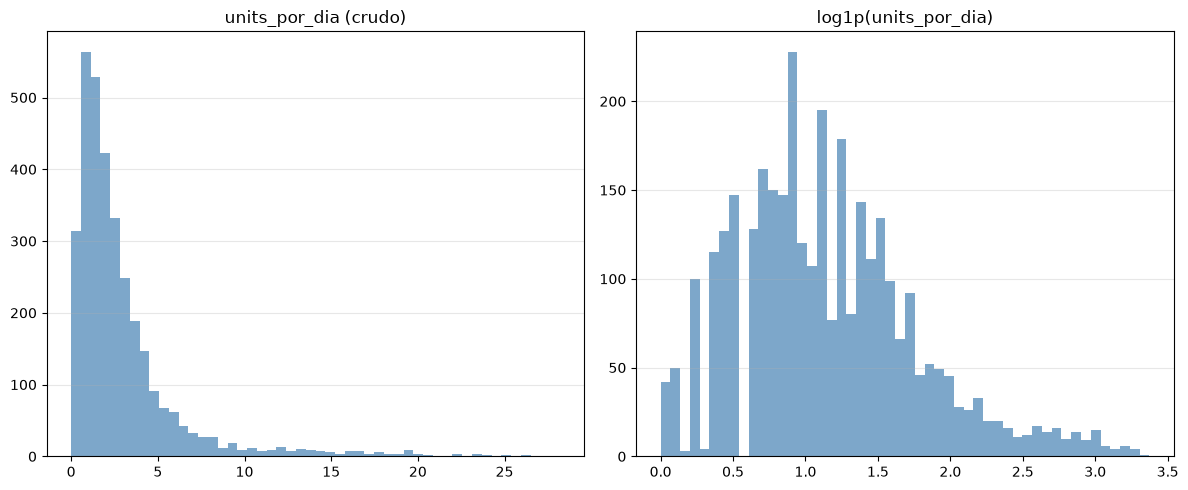

In [47]:
# ── 11.1 Target transformado para EDA/correlación (log1p, según Sección 8) ──

panel_final['log_units_por_dia'] = np.log1p(panel_final['units_por_dia'])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(panel_final['units_por_dia'], bins=50, color='steelblue', alpha=0.7)
axes[0].set_title('units_por_dia (crudo)')
axes[0].grid(axis='y', alpha=0.3)
axes[1].hist(panel_final['log_units_por_dia'], bins=50, color='steelblue', alpha=0.7)
axes[1].set_title('log1p(units_por_dia)')
axes[1].grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'target_log_vs_crudo.png', dpi=150, bbox_inches='tight')
plt.show()

In [48]:
# ── 11.2 Correlación con el target: global (mezclada) vs. within (por artículo) ──

columnas_numericas = [
    'n_dias_finde', 'n_dias_festivo', 'n_dias_evento', 'intensidad_evento_total',
    'temperature_mean_periodo', 'temperature_max_periodo', 'temperature_min_periodo',
    'precipitation_mm_total', 'precipitation_hours_total', 'wind_speed_max_periodo',
    'sunshine_duration_h_total', 'n_reservas_total_periodo', 'comensales_completada_periodo',
    'tasa_no_show_media', 'tasa_cancelacion_media', 'sugerencias'
]

panel_within = panel_final.copy()
for col in ['log_units_por_dia'] + columnas_numericas:
    media_articulo = panel_within.groupby('article_code', observed=True)[col].transform('mean')
    panel_within[col + '_within'] = panel_within[col] - media_articulo

resultados_corr = []
for col in columnas_numericas:
    corr_global_pearson = panel_final['log_units_por_dia'].corr(panel_final[col], method='pearson')
    corr_global_spearman = panel_final['log_units_por_dia'].corr(panel_final[col], method='spearman')
    corr_within = panel_within['log_units_por_dia_within'].corr(panel_within[col + '_within'])
    resultados_corr.append({
        'variable': col,
        'corr_global_pearson': round(corr_global_pearson, 3),
        'corr_global_spearman': round(corr_global_spearman, 3),
        'corr_within': round(corr_within, 3),
    })

resultados_corr = pd.DataFrame(resultados_corr).sort_values('corr_within', key=abs, ascending=False)
print("Ordenado por |correlación within| — el criterio principal:")
display(resultados_corr)

Ordenado por |correlación within| — el criterio principal:


,variable,corr_global_pearson,corr_global_spearman,corr_within
12,comensales_completada_periodo,0.097,0.106,0.219
11,n_reservas_total_periodo,0.092,0.100,0.207
3,intensidad_evento_total,0.042,0.040,0.094
6,temperature_min_periodo,0.029,0.038,0.064
2,n_dias_evento,0.025,0.026,0.056
9,wind_speed_max_periodo,-0.023,-0.024,-0.052
4,temperature_mean_periodo,0.023,0.033,0.051
5,temperature_max_periodo,0.021,0.031,0.048
10,sunshine_duration_h_total,0.019,0.017,0.042
8,precipitation_hours_total,0.012,0.011,0.028


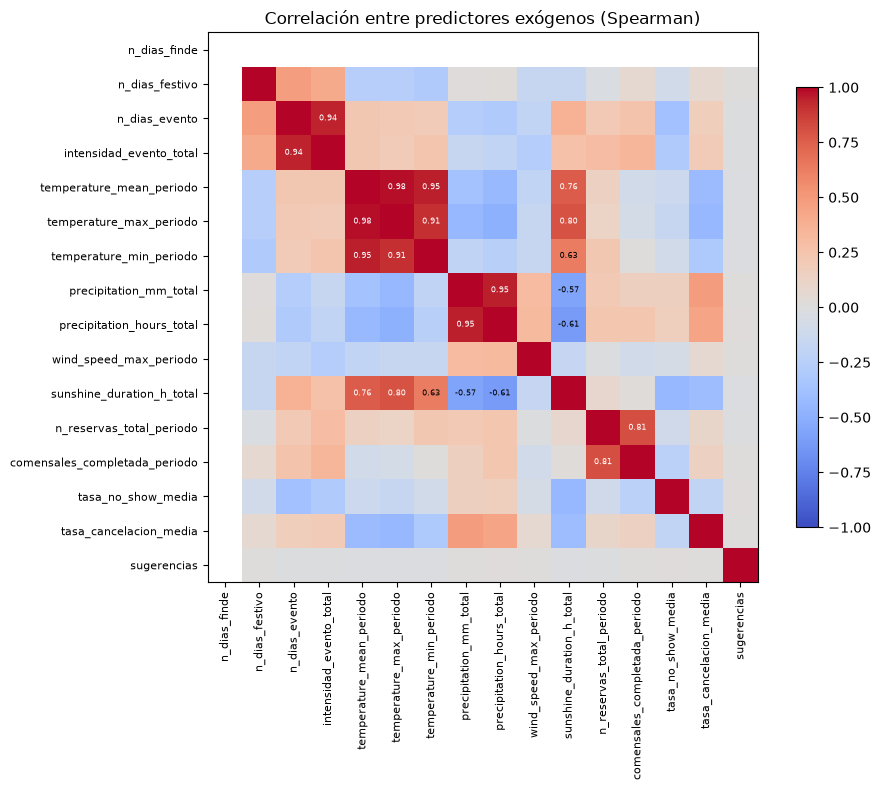

Pares de predictores con |correlación| > 0.7 (candidatos a redundancia):
  n_dias_evento <-> intensidad_evento_total: 0.94
  temperature_mean_periodo <-> temperature_max_periodo: 0.98
  temperature_mean_periodo <-> temperature_min_periodo: 0.95
  temperature_mean_periodo <-> sunshine_duration_h_total: 0.76
  temperature_max_periodo <-> temperature_min_periodo: 0.91
  temperature_max_periodo <-> sunshine_duration_h_total: 0.8
  precipitation_mm_total <-> precipitation_hours_total: 0.95
  n_reservas_total_periodo <-> comensales_completada_periodo: 0.81


In [49]:
# ── 11.3 Multicolinealidad entre predictores exógenos ───────────────────────

corr_predictores = panel_final[columnas_numericas].corr(method='spearman').round(2)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_predictores.values, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(columnas_numericas)))
ax.set_yticks(range(len(columnas_numericas)))
ax.set_xticklabels(columnas_numericas, rotation=90, fontsize=8)
ax.set_yticklabels(columnas_numericas, fontsize=8)
plt.colorbar(im, ax=ax, shrink=0.8)
for i in range(len(columnas_numericas)):
    for j in range(len(columnas_numericas)):
        val = corr_predictores.values[i, j]
        if abs(val) > 0.5 and i != j:
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=6,
                     color='white' if abs(val) > 0.75 else 'black')
ax.set_title('Correlación entre predictores exógenos (Spearman)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'multicolinealidad_predictores.png', dpi=150, bbox_inches='tight')
plt.show()

print("Pares de predictores con |correlación| > 0.7 (candidatos a redundancia):")
pares_altos = []
for i in range(len(columnas_numericas)):
    for j in range(i + 1, len(columnas_numericas)):
        val = corr_predictores.iloc[i, j]
        if abs(val) > 0.7:
            pares_altos.append((columnas_numericas[i], columnas_numericas[j], val))
            print(f"  {columnas_numericas[i]} <-> {columnas_numericas[j]}: {val}")
if not pares_altos:
    print("  Ninguno por encima del umbral.")

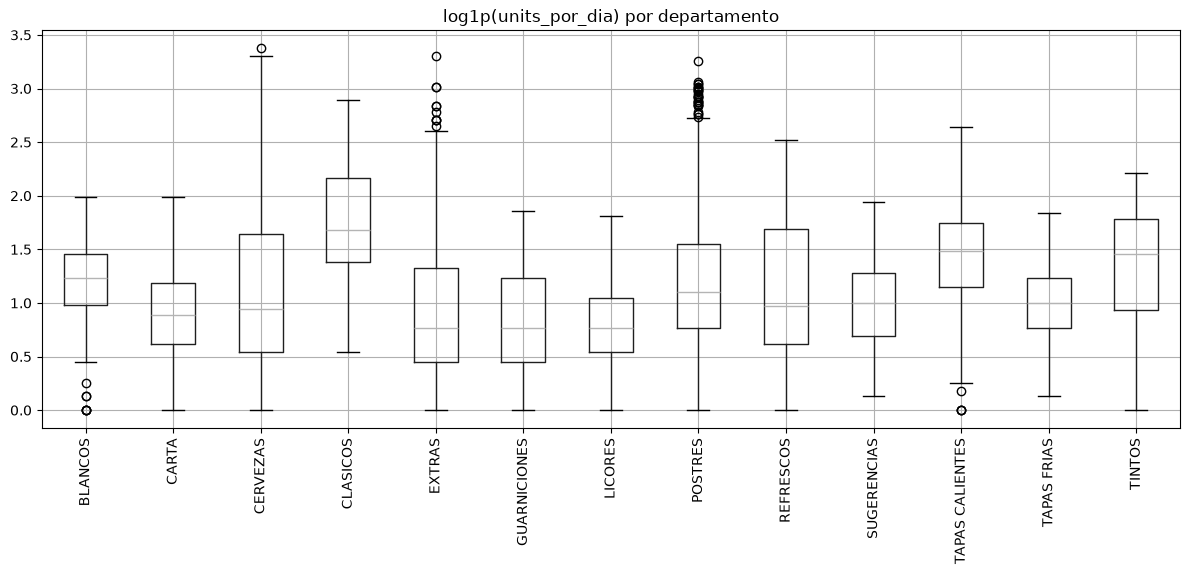

log_units_por_dia según sugerencias (0=carta/otro, 1=sugerencia ese periodo):


,mean,std,count
sugerencias,,,
0,1.163683,0.633537,3014
1,0.988084,0.419448,266


In [50]:
# ── 11.4 Categóricas vs. target: departamento y sugerencias ─────────────────

fig, ax = plt.subplots(figsize=(12, 6))
panel_final.boxplot(column='log_units_por_dia', by='department_name_final', ax=ax, rot=90)
plt.suptitle('')
ax.set_title('log1p(units_por_dia) por departamento')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'target_por_departamento.png', dpi=150, bbox_inches='tight')
plt.show()

print("log_units_por_dia según sugerencias (0=carta/otro, 1=sugerencia ese periodo):")
display(panel_final.groupby('sugerencias')['log_units_por_dia'].agg(['mean', 'std', 'count']))

In [51]:
# ── 11.5 Confirmar por qué n_dias_finde da NaN ──────────────────────────────
print(f"Valores únicos de n_dias_finde: {panel_final['n_dias_finde'].unique()}")
print(f"Varianza: {panel_final['n_dias_finde'].var()}")

Valores únicos de n_dias_finde: [2]
Varianza: 0.0


In [52]:
# ── 11.6 Autocorrelación de units_por_dia dentro de cada artículo (lag 1) ───

panel_ordenado = panel_final.sort_values(['article_code', 'report_start'])
panel_ordenado['lag1_units_por_dia'] = panel_ordenado.groupby('article_code', observed=True)['units_por_dia'].shift(1)

autocorr_lag1 = panel_ordenado['units_por_dia'].corr(panel_ordenado['lag1_units_por_dia'])
print(f"Autocorrelación lag-1 (venta esta semana vs. semana anterior, mismo artículo): {autocorr_lag1:.3f}")

Autocorrelación lag-1 (venta esta semana vs. semana anterior, mismo artículo): 0.887


In [53]:
# ── 11.6b Autocorrelación lag-1, versión within (la que realmente importa) ──

panel_ordenado = panel_final.sort_values(['article_code', 'report_start']).copy()
panel_ordenado['lag1_units_por_dia'] = panel_ordenado.groupby('article_code', observed=True)['units_por_dia'].shift(1)

# Centramos ambas series por su media dentro de cada artículo
media_por_articulo = panel_ordenado.groupby('article_code', observed=True)['units_por_dia'].transform('mean')
panel_ordenado['units_within'] = panel_ordenado['units_por_dia'] - media_por_articulo
panel_ordenado['lag1_within'] = panel_ordenado['lag1_units_por_dia'] - media_por_articulo

autocorr_within = panel_ordenado['units_within'].corr(panel_ordenado['lag1_within'])
print(f"Autocorrelación lag-1, within (controlando el nivel medio de cada artículo): {autocorr_within:.3f}")

Autocorrelación lag-1, within (controlando el nivel medio de cada artículo): 0.249


#### Conclusiones

**Hallazgo principal: la señal disponible, exógena o de la propia serie, es modesta —
no hay ninguna variable individual con correlación *within* fuerte.** Ninguna variable de
calendario, clima o eventos supera 0.1. Las tres con mayor señal, todas en un rango similar
y moderado, son:

| Variable | Correlación *within* |
|---|---|
| lag-1 (venta de la semana anterior, mismo artículo) | 0.249 |
| comensales_completada_periodo | 0.219/0.220 |
| n_reservas_total_periodo | 0.201 |

**Aviso metodológico explícito**: el cálculo inicial de autocorrelación lag-1 sobre
`units_por_dia` sin centrar dio 0.887 — una cifra engañosa, inflada por el mismo efecto
*between* que ya se había corregido para el resto de variables (cada artículo mantiene un
nivel de venta propio y estable, así que "la semana anterior" correlaciona alto con "esta
semana" simplemente por tratarse del mismo artículo, no por inercia real de demanda). Al
centrar por la media de cada artículo, la cifra cae a 0.249. Se documenta el contraste
porque es un error fácil de cometer y de pasar desapercibido si no se aplica el mismo
criterio *within*/*between* de forma sistemática a todas las variables, incluidas las
derivadas de la propia serie.

**`n_dias_finde` se elimina de los predictores**: varianza cero.

**Multicolinealidad confirmada en tres bloques esperables**: temperaturas entre sí
(0.91–0.98), lluvia mm/horas (0.95), eventos conteo/intensidad (0.94), reservas/comensales
(0.79). Un representante por bloque para la interpretabilidad de la Sección 16:
`temperature_mean_periodo`, `precipitation_mm_total`, `intensidad_evento_total`,
`comensales_completada_periodo`.

**Departamento** tiene variación real entre categorías, pero ya capturada por `article_code`
— no se añade como predictor aparte. **`sugerencias`** no muestra diferencia relevante.

**Consecuencia para la Sección 12 y para las expectativas de la Sección 14**: ninguna
variable disponible, exógena o de lag, ofrece señal fuerte de forma aislada. El modelo va a
depender de la combinación de varias señales moderadas (`article_code` + lag-1 + comensales/
reservas + algo de clima/eventos residual) más que de una variable dominante. Esto es
importante fijarlo como expectativa **antes** de entrenar el modelo: un R² o una precisión
modestos no serán un fallo del modelado, serán consistentes con lo que el propio EDA ya
adelanta sobre el techo de señal disponible en estos datos a granularidad semanal.

### 12. Feature engineering final

Con el diagnóstico de la Sección 11 ya fijado (señal moderada, repartida entre varias
variables, sin ninguna dominante), esta sección construye las features definitivas del
modelo. Tres decisiones antes del código:

- **Lags y rolling windows agrupados por `article_code`**, sin excepción — es el riesgo de
  fuga que ya se avisó en la Sección 6 (mezclar series de artículos distintos al calcular
  un `shift` sin agrupar antes).
- **Economía de lags**: con solo 40 periodos por artículo, cada lag introducido resta filas
  utilizables al inicio de cada serie (el primer periodo de cada artículo nunca tiene lag-1).
  No se añaden lags "porque sí" — cada uno se valida con su correlación *within* antes de
  comprometerse a él, igual que se hizo con el resto de variables en la Sección 11.
- **Reducción de multicolinealidad**: se aplica ya aquí la recomendación de la Sección 11 —
  un representante por bloque de variables redundantes (`temperature_mean_periodo`,
  `precipitation_mm_total`, `intensidad_evento_total`, `comensales_completada_periodo`),
  el resto de variables del mismo bloque se dejan fuera del set final de predictores.

In [54]:
# ── 12.1 Construcción de candidatos de memoria temporal ─────────────────────
# Todos con shift(1) ANTES de cualquier rolling/ewm — si no, la fila de la
# semana actual se cuela dentro de su propia media suavizada (fuga directa).
# Todo agrupado por article_code: nunca mezclar series de artículos distintos.

panel_features = panel_final.sort_values(['article_code', 'report_start']).copy()

g = panel_features.groupby('article_code', observed=True)['units_por_dia']

panel_features['lag_1'] = g.shift(1)
panel_features['lag_2'] = g.shift(2)
panel_features['rolling_mean_3'] = g.shift(1).rolling(3).mean().reset_index(level=0, drop=True)
panel_features['ewma_span3'] = g.transform(lambda s: s.shift(1).ewm(span=3, min_periods=1).mean())

print(f"Panel con candidatos de memoria temporal: {panel_features.shape[0]} filas x {panel_features.shape[1]} columnas")

Panel con candidatos de memoria temporal: 3280 filas x 33 columnas


In [55]:
# ── 12.2 Validación: correlación within de cada candidato ───────────────────

def corr_within(df, col_a, col_b):
    media_a = df.groupby('article_code', observed=True)[col_a].transform('mean')
    media_b = df.groupby('article_code', observed=True)[col_b].transform('mean')
    return (df[col_a] - media_a).corr(df[col_b] - media_b)

resultados_lags = []
for col in ['lag_1', 'lag_2', 'rolling_mean_3', 'ewma_span3']:
    valido = panel_features.dropna(subset=[col, 'units_por_dia'])
    resultados_lags.append({
        'variable': col,
        'corr_within': round(corr_within(valido, 'units_por_dia', col), 3),
        'n_filas_validas': len(valido),
    })

resultados_lags = pd.DataFrame(resultados_lags).sort_values('corr_within', ascending=False)
display(resultados_lags)

,variable,corr_within,n_filas_validas
3,ewma_span3,0.262,3198
0,lag_1,0.249,3198
2,rolling_mean_3,0.228,3034
1,lag_2,0.153,3116


In [56]:
# ── 12.3 Selección final: lag_1 + ewma_span3 ─────────────────────────────────
# lag_2 y rolling_mean_3 quedan dominados por ewma_span3 (peor correlación
# within Y más filas perdidas) — se descartan del set final de predictores.

panel_features = panel_features.drop(columns=['lag_2', 'rolling_mean_3'])

print("Memoria temporal final: lag_1, ewma_span3")
print(f"Panel features: {panel_features.shape[0]} filas x {panel_features.shape[1]} columnas")

Memoria temporal final: lag_1, ewma_span3
Panel features: 3280 filas x 31 columnas


In [57]:
# ── 12.4 Reducción de multicolinealidad (un representante por bloque, Sección 11) ──

COLUMNAS_REDUNDANTES = [
    'temperature_max_periodo', 'temperature_min_periodo',  # bloque temperatura
    'precipitation_hours_total',                             # bloque precipitación
    'n_dias_evento',                                          # bloque eventos
    'n_reservas_total_periodo',                               # bloque reservas/comensales
    'n_dias_finde',                                           # varianza cero
]

panel_features = panel_features.drop(columns=COLUMNAS_REDUNDANTES)
print(f"Columnas eliminadas por redundancia/varianza cero: {len(COLUMNAS_REDUNDANTES)}")
print(f"Panel features: {panel_features.shape[0]} filas x {panel_features.shape[1]} columnas")

Columnas eliminadas por redundancia/varianza cero: 6
Panel features: 3280 filas x 25 columnas


In [58]:
# ── 12.5 Encoding de article_code para modelos sin soporte nativo de categóricas ──
# article_code ya es 'category' (válido para LightGBM/CatBoost sin más).
# article_code_encoded es la alternativa ordinal para RandomForest/XGBoost clásico.

panel_features['article_code_encoded'] = panel_features['article_code'].cat.codes

In [59]:
# ── 12.6 Filas perdidas por los lags: cuantificación final ──────────────────

n_filas_con_nan = panel_features[['lag_1', 'ewma_span3']].isna().any(axis=1).sum()
n_filas_utilizables = len(panel_features) - n_filas_con_nan

print(f"Filas con NaN en lag_1/ewma_span3: {n_filas_con_nan} de {len(panel_features)}")
print(f"Filas utilizables para entrenar: {n_filas_utilizables} ({n_filas_utilizables / len(panel_features) * 100:.1f}%)")

# Confirmación de que la pérdida es exactamente 1 fila por artículo (la primera de cada serie)
perdidas_por_articulo = panel_features.groupby('article_code', observed=True)['lag_1'].apply(lambda s: s.isna().sum())
print(f"\n¿Todos los artículos pierden exactamente 1 fila?: {(perdidas_por_articulo == 1).all()}")
if not (perdidas_por_articulo == 1).all():
    print("⚠️  Algún artículo pierde un número distinto de filas — revisar antes de continuar:")
    display(perdidas_por_articulo[perdidas_por_articulo != 1])

display(panel_features.head(10))

Filas con NaN en lag_1/ewma_span3: 82 de 3280
Filas utilizables para entrenar: 3198 (97.5%)

¿Todos los artículos pierden exactamente 1 fila?: True


,article_code,article_name,department_name_final,department_code_final,report_start,report_end,duracion_periodo,units,amount,precio_unitario,sugerencias,units_por_dia,mes_periodo,n_dias_festivo,intensidad_evento_total,temperature_mean_periodo,precipitation_mm_total,wind_speed_max_periodo,sunshine_duration_h_total,comensales_completada_periodo,tasa_no_show_media,tasa_cancelacion_media,log_units_por_dia,lag_1,ewma_span3,article_code_encoded
0,1,NUESTRAS CROQUETAS DE JAMON,CLASICOS,28,2025-10-01,2025-10-05,5,28.0,151.63644,5.415587,0,5.600000,10,0,0,20.350000,0.0,17.5,45.763494,284,5.535000,5.270000,1.887070,NaN,NaN,0
1,1,NUESTRAS CROQUETAS DE JAMON,CLASICOS,28,2025-10-06,2025-10-12,7,32.0,198.18195,6.193186,0,4.571429,10,0,6,19.233333,0.0,17.2,57.373686,420,2.873333,9.608333,1.717651,5.600000,5.600000,0
2,1,NUESTRAS CROQUETAS DE JAMON,CLASICOS,28,2025-10-13,2025-10-19,7,20.0,112.18190,5.609095,0,2.857143,10,0,4,17.333333,11.0,15.0,59.263197,273,3.311667,10.720000,1.349927,4.571429,4.914286,0
3,1,NUESTRAS CROQUETAS DE JAMON,CLASICOS,28,2025-10-20,2025-10-26,7,28.0,155.81828,5.564939,0,4.000000,10,0,0,16.250000,3.9,24.5,52.128892,371,2.356667,6.895000,1.609438,2.857143,3.738776,0
4,1,NUESTRAS CROQUETAS DE JAMON,CLASICOS,28,2025-10-27,2025-11-02,7,18.0,107.63643,5.979802,0,2.571429,10,1,6,12.583333,16.6,17.1,29.075719,368,2.463333,10.758333,1.272966,4.000000,3.878095,0
5,1,NUESTRAS CROQUETAS DE JAMON,CLASICOS,28,2025-11-03,2025-11-09,7,24.0,145.09101,6.045459,0,3.428571,11,0,0,9.816667,28.4,19.5,47.003731,363,1.856667,14.438333,1.488077,2.571429,3.203687,0
6,1,NUESTRAS CROQUETAS DE JAMON,CLASICOS,28,2025-11-10,2025-11-16,7,26.0,156.00007,6.000003,0,3.714286,11,0,0,11.050000,36.5,27.0,32.768925,441,1.596667,13.693333,1.550597,3.428571,3.317914,0
7,1,NUESTRAS CROQUETAS DE JAMON,CLASICOS,28,2025-11-17,2025-11-23,7,28.0,195.27281,6.974029,0,4.000000,11,0,0,5.083333,0.0,16.7,52.606364,401,0.505000,6.866667,1.609438,3.714286,3.517660,0
8,1,NUESTRAS CROQUETAS DE JAMON,CLASICOS,28,2025-11-24,2025-11-30,7,23.0,153.81825,6.687750,0,3.285714,11,0,3,5.666667,2.7,20.9,54.243728,406,1.388333,15.283333,1.455287,4.000000,3.759776,0
9,1,NUESTRAS CROQUETAS DE JAMON,CLASICOS,28,2025-12-01,2025-12-07,7,28.0,181.09097,6.467535,0,4.000000,12,1,18,7.333333,6.2,23.4,37.439672,433,1.786667,11.010000,1.609438,3.285714,3.522281,0


#### Conclusiones

**Memoria temporal**: se evaluaron cuatro candidatos (`lag_1`, `lag_2`, `rolling_mean_3`,
`ewma_span3`), calculados siempre con `shift(1)` antes de cualquier suavizado y agrupados
por `article_code` para evitar mezclar series de artículos distintos. `ewma_span3` resultó
la mejor opción en las dos dimensiones que importan: mayor correlación *within* (0.262 frente
a 0.249 de `lag_1`, 0.228 de `rolling_mean_3`) y menor pérdida de filas (82, las mismas que
`lag_1`, frente a las 246 de `rolling_mean_3`). Se mantienen `lag_1` y `ewma_span3` en el set
final; `lag_2` y `rolling_mean_3` quedan descartados por estar dominados por `ewma_span3` en
ambos criterios.

**Reducción de multicolinealidad**: se eliminan 6 columnas redundantes o sin varianza,
siguiendo el criterio fijado en la Sección 11 — un representante por bloque de variables
correlacionadas (`temperature_max_periodo`, `temperature_min_periodo`,
`precipitation_hours_total`, `n_dias_evento`, `n_reservas_total_periodo` eliminadas;
`n_dias_finde` eliminada por varianza cero).

**Encoding**: `article_code_encoded` (ordinal) queda disponible como alternativa a
`article_code` (categórica nativa) según el modelo elegido en la Sección 14.

**Pérdida de datos por lags**: 82 de 3.280 filas (2.5%) quedan sin `lag_1`/`ewma_span3` —
exactamente la primera fila de cada uno de los 82 artículos, sin excepciones ni patrones
irregulares. Quedan **3.198 filas utilizables (97.5%)** para entrenar el modelo.

**Panel features final**: 3.280 filas x 25 columnas (3.198 utilizables tras eliminar las
filas sin lag), combinando target, identificación, 10 variables exógenas no redundantes,
memoria temporal (`lag_1`, `ewma_span3`) y encoding de artículo. Listo para la Sección 13
(split temporal train/test).

### 13. Split temporal train/test

El panel tiene 39 periodos utilizables por artículo (se descarta el primero de cada serie
por no tener `lag_1`/`ewma_span3`, Sección 12). Con series tan cortas, dos decisiones no son
opcionales, son las que determinan si la validación es honesta o no:

- **Corte único por fecha, aplicado a los 82 artículos a la vez** — nunca splits
  independientes por artículo. Si cada artículo se cortara en un punto distinto, el modelo
  podría estar "viendo" datos de un artículo que temporalmente son posteriores a los que se
  le piden predecir de otro — eso es fuga de información a través del panel, aunque cada
  serie individual esté bien ordenada.
- **Nunca aleatorio** — el test set tiene que ser estrictamente posterior en el tiempo al
  train set. Un split aleatorio dejaría que el modelo aprenda de "la semana siguiente" para
  predecir "la semana anterior", algo que nunca podría hacer en producción real.

Con solo 39 periodos, el margen para el test set es estrecho: un test demasiado grande dejaría
muy poco train (el modelo no aprendería bien la estacionalidad); uno demasiado pequeño no daría
una estimación fiable del error. Se opta por un **85/15 aproximado** (33 periodos train, 6
periodos test) — se decide con el propio dato del split, no un porcentaje fijo de antemano.

In [60]:
# ── 13.1 Dataset de modelado: solo filas con lag/ewma disponibles ───────────

dataset_modelo = panel_features.dropna(subset=['lag_1', 'ewma_span3']).copy()
print(f"Dataset de modelado: {dataset_modelo.shape[0]} filas x {dataset_modelo.shape[1]} columnas")

periodos_disponibles = sorted(dataset_modelo['report_start'].unique())
print(f"Periodos disponibles para modelar: {len(periodos_disponibles)}")

Dataset de modelado: 3198 filas x 26 columnas
Periodos disponibles para modelar: 39


In [61]:
# ── 13.2 Corte temporal: últimos 6 periodos como test ───────────────────────

N_PERIODOS_TEST = 6
fecha_corte = periodos_disponibles[-N_PERIODOS_TEST]

print(f"\nFecha de corte: {fecha_corte.date()}")
print(f"Train: periodos {periodos_disponibles[0].date()} a {periodos_disponibles[-N_PERIODOS_TEST - 1].date()}")
print(f"Test:  periodos {periodos_disponibles[-N_PERIODOS_TEST].date()} a {periodos_disponibles[-1].date()}")

train = dataset_modelo[dataset_modelo['report_start'] < fecha_corte].copy()
test = dataset_modelo[dataset_modelo['report_start'] >= fecha_corte].copy()

print(f"\nTrain: {len(train)} filas ({len(train) / len(dataset_modelo) * 100:.1f}%)")
print(f"Test:  {len(test)} filas ({len(test) / len(dataset_modelo) * 100:.1f}%)")


Fecha de corte: 2026-05-25
Train: periodos 2025-10-06 a 2026-05-18
Test:  periodos 2026-05-25 a 2026-06-29

Train: 2706 filas (84.6%)
Test:  492 filas (15.4%)


In [62]:
# ── 13.3 Verificaciones de integridad del split ──────────────────────────────

print(f"\n¿Algún solapamiento de fechas entre train y test?: "
      f"{train['report_start'].max() >= test['report_start'].min()}")

articulos_train = set(train['article_code'])
articulos_test = set(test['article_code'])
print(f"Artículos en train: {len(articulos_train)}")
print(f"Artículos en test: {len(articulos_test)}")
print(f"¿Todos los artículos del panel están en ambos conjuntos?: "
      f"{articulos_train == articulos_test == set(dataset_modelo['article_code'])}")

filas_por_articulo_test = test.groupby('article_code', observed=True).size()
print(f"\n¿Todos los artículos tienen el mismo nº de filas en test?: "
      f"{(filas_por_articulo_test == N_PERIODOS_TEST).all()}")
if not (filas_por_articulo_test == N_PERIODOS_TEST).all():
    display(filas_por_articulo_test[filas_por_articulo_test != N_PERIODOS_TEST])


¿Algún solapamiento de fechas entre train y test?: False
Artículos en train: 82
Artículos en test: 82
¿Todos los artículos del panel están en ambos conjuntos?: True

¿Todos los artículos tienen el mismo nº de filas en test?: True


#### Conclusiones

**Corte fijado en 2026-05-25**, aplicado a los 82 artículos simultáneamente:

- **Train**: 2025-10-06 a 2026-05-18 (33 periodos) — 2.706 filas (84.6%)
- **Test**: 2026-05-25 a 2026-06-29 (6 periodos) — 492 filas (15.4%)

**Verificaciones de integridad**, todas superadas:
- Sin solapamiento temporal entre train y test.
- Los 82 artículos están presentes en ambos conjuntos, con exactamente 6 filas en test cada
  uno — confirma que ningún artículo perdió filas adicionales por `NaN` en un punto intermedio
  de su serie, más allá de la primera fila ya descontada en la Sección 12.

**Aviso para la interpretación de resultados (Sección 15)**: el periodo de test (fin de mayo
a finales de junio) cae en la parte final del histórico disponible, sin repetición de ese
tramo del año en el train — el modelo no ha visto ningún junio/mayo anterior de este negocio
(el histórico arranca en octubre 2025). Cualquier estacionalidad anual o de temporada alta
propia de esas fechas no puede haberse aprendido de datos análogos previos; solo se apoya en
lo que las variables exógenas (clima, festivos, eventos) y los lags capturen de forma
genérica. Es una limitación estructural del tamaño del histórico, no del split en sí, y debe
quedar explícita si el modelo rinde peor en test que en validación cruzada dentro del train.

**Dataset final para la Sección 14**: `train` (2.706 filas) y `test` (492 filas), ambos con
las mismas 25 columnas del panel features, listos para seleccionar el conjunto de predictores
y entrenar el modelo.

### 14. Modelado

Con el diagnóstico de la Sección 11 en mente (señal moderada, sin ninguna variable
dominante) y siguiendo el criterio de "varias técnicas justificadas" que pide la guía del
TFM, se entrenan tres modelos de complejidad creciente, no arbitrarios:

- **Baseline de persistencia** (predicción = `lag_1`, sin entrenar nada): el punto de
  referencia obligado en cualquier problema de series temporales. Si un modelo "sofisticado"
  no le gana a "vender esta semana lo mismo que la semana pasada", no aporta nada real.
- **Ridge (regresión lineal regularizada)**: modelo interpretable, con `article_code`
  codificado como dummies. Sirve para ver si una relación lineal simple ya captura buena
  parte de la señal, y da coeficientes fáciles de explicar en la Sección 16.
- **HistGradientBoostingRegressor** (scikit-learn, boosting de árboles): maneja
  `article_code` como categórica nativa sin necesidad de one-hot, captura interacciones no
  lineales entre variables, y es el enfoque estándar en forecasting de demanda multi-producto
  — la elección justificada en la Sección 6 al decidir el modelo panel.

Los tres se entrenan sobre el mismo `train`/`test` de la Sección 13, con el ajuste de
cualquier transformación (escalado, codificación) hecho **solo sobre train** — ajustarlo
sobre el conjunto completo antes de dividir sería una fuga de información, aunque pequeña.

In [63]:
# ── 14.1 Selección de features y separación X/y ──────────────────────────────

FEATURES_NUMERICAS = [
    'n_dias_festivo', 'intensidad_evento_total', 'temperature_mean_periodo',
    'precipitation_mm_total', 'wind_speed_max_periodo', 'sunshine_duration_h_total',
    'comensales_completada_periodo', 'tasa_no_show_media', 'tasa_cancelacion_media',
    'sugerencias', 'lag_1', 'ewma_span3',
]
FEATURE_CATEGORICA = 'article_code'  # mes_periodo se deja fuera por ahora: solo 33 periodos
                                       # de train cubren 8 meses distintos, poca repetición
                                       # por categoría — se revisa si hace falta en la Sección 16
TARGET = 'units_por_dia'

X_train = train[FEATURES_NUMERICAS + [FEATURE_CATEGORICA]].copy()
y_train = train[TARGET].copy()
X_test = test[FEATURES_NUMERICAS + [FEATURE_CATEGORICA]].copy()
y_test = test[TARGET].copy()

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Features numéricas: {len(FEATURES_NUMERICAS)}")

X_train: (2706, 13), X_test: (492, 13)
Features numéricas: 12


In [64]:
# ── 14.2 Baseline de persistencia (sin entrenamiento) ────────────────────────

pred_baseline = X_test['lag_1'].values

print("Baseline de persistencia: predicción = venta de la semana anterior, mismo artículo")
print(f"Ejemplo — primeras 5 predicciones: {pred_baseline[:5].round(2)}")

Baseline de persistencia: predicción = venta de la semana anterior, mismo artículo
Ejemplo — primeras 5 predicciones: [4.43 5.   5.86 4.43 4.57]


In [65]:
# ── 14.3 Modelo Ridge (interpretable), article_code como one-hot ────────────

preprocesador_ridge = ColumnTransformer([
    ('numericas', StandardScaler(), FEATURES_NUMERICAS),
    ('articulo', OneHotEncoder(handle_unknown='ignore'), [FEATURE_CATEGORICA]),
])

modelo_ridge = Pipeline([
    ('preprocesado', preprocesador_ridge),
    ('regresion', Ridge(alpha=1.0)),
])

modelo_ridge.fit(X_train, y_train)
pred_ridge = modelo_ridge.predict(X_test)

print("Modelo Ridge entrenado.")
print(f"Ejemplo — primeras 5 predicciones: {pred_ridge[:5].round(2)}")

Modelo Ridge entrenado.
Ejemplo — primeras 5 predicciones: [3.57 4.26 3.91 4.09 3.89]


In [66]:
# ── 14.4 HistGradientBoostingRegressor, article_code como categórica nativa ──

X_train_hgb = X_train.copy()
X_test_hgb = X_test.copy()
X_train_hgb[FEATURE_CATEGORICA] = X_train_hgb[FEATURE_CATEGORICA].astype('category')
X_test_hgb[FEATURE_CATEGORICA] = X_test_hgb[FEATURE_CATEGORICA].astype('category')

modelo_hgb = HistGradientBoostingRegressor(
    categorical_features=[FEATURE_CATEGORICA],
    random_state=42,
    max_iter=200,
)

modelo_hgb.fit(X_train_hgb, y_train)
pred_hgb = modelo_hgb.predict(X_test_hgb)

print("Modelo HistGradientBoostingRegressor entrenado.")
print(f"Ejemplo — primeras 5 predicciones: {pred_hgb[:5].round(2)}")

Modelo HistGradientBoostingRegressor entrenado.
Ejemplo — primeras 5 predicciones: [3.93 4.04 4.1  3.71 3.69]


In [67]:
# ── 14.5 Comparación preliminar (análisis completo en la Sección 15) ────────

resultados_preliminares = pd.DataFrame({
    'modelo': ['Baseline (persistencia)', 'Ridge', 'HistGradientBoosting'],
    'MAE': [
        mean_absolute_error(y_test, pred_baseline),
        mean_absolute_error(y_test, pred_ridge),
        mean_absolute_error(y_test, pred_hgb),
    ],
    'RMSE': [
        mean_squared_error(y_test, pred_baseline) ** 0.5,
        mean_squared_error(y_test, pred_ridge) ** 0.5,
        mean_squared_error(y_test, pred_hgb) ** 0.5,
    ],
}).round(3)

display(resultados_preliminares)

,modelo,MAE,RMSE
0,Baseline (persistencia),0.965,1.532
1,Ridge,0.802,1.241
2,HistGradientBoosting,0.940,1.499


In [68]:
# ── 14.6 Diagnóstico: ¿HistGradientBoosting está sobreajustando? ────────────

mae_hgb_train = mean_absolute_error(y_train, modelo_hgb.predict(X_train_hgb))
mae_hgb_test = mean_absolute_error(y_test, pred_hgb)
mae_ridge_train = mean_absolute_error(y_train, modelo_ridge.predict(X_train))
mae_ridge_test = mean_absolute_error(y_test, pred_ridge)

print(f"HistGradientBoosting — MAE train: {mae_hgb_train:.3f} | MAE test: {mae_hgb_test:.3f}")
print(f"Ridge                — MAE train: {mae_ridge_train:.3f} | MAE test: {mae_ridge_test:.3f}")

HistGradientBoosting — MAE train: 0.340 | MAE test: 0.940
Ridge                — MAE train: 0.770 | MAE test: 0.802


In [69]:
# ── 14.7 Referencia adicional: baseline con EWMA en vez de lag_1 ────────────
# ewma_span3 tenía mayor corr. within que lag_1 (Sección 12) — vale la pena
# ver si un "baseline mejorado" ya se acerca a Ridge, para calibrar cuánto
# aporta de verdad el modelo entrenado sobre simplemente usar ewma directo.

pred_baseline_ewma = X_test['ewma_span3'].values
mae_baseline_ewma = mean_absolute_error(y_test, pred_baseline_ewma)
print(f"Baseline EWMA (sin entrenar) — MAE: {mae_baseline_ewma:.3f}")

Baseline EWMA (sin entrenar) — MAE: 0.818


In [70]:
# ── 14.8 HistGradientBoosting regularizado ───────────────────────────────────

modelo_hgb_reg = HistGradientBoostingRegressor(
    categorical_features=[FEATURE_CATEGORICA],
    random_state=42,
    max_iter=200,
    max_depth=3,                 # árboles más simples, menos capacidad de memorizar
    l2_regularization=1.0,       # penalización explícita, por defecto es 0
    early_stopping=True,         # para de entrenar si deja de mejorar en validación interna
    validation_fraction=0.2,
    n_iter_no_change=10,
)

modelo_hgb_reg.fit(X_train_hgb, y_train)

pred_hgb_reg_train = modelo_hgb_reg.predict(X_train_hgb)
pred_hgb_reg_test = modelo_hgb_reg.predict(X_test_hgb)

mae_hgb_reg_train = mean_absolute_error(y_train, pred_hgb_reg_train)
mae_hgb_reg_test = mean_absolute_error(y_test, pred_hgb_reg_test)

print(f"HistGradientBoosting regularizado — MAE train: {mae_hgb_reg_train:.3f} | MAE test: {mae_hgb_reg_test:.3f}")
print(f"Nº de árboles usados (early stopping): {modelo_hgb_reg.n_iter_}")

HistGradientBoosting regularizado — MAE train: 0.690 | MAE test: 0.817
Nº de árboles usados (early stopping): 63


In [71]:
# ── 14.9 Tabla comparativa completa, los 5 candidatos ────────────────────────

mae_baseline = mean_absolute_error(y_test, pred_baseline)

resultados_finales = pd.DataFrame({
    'modelo': ['Baseline (persistencia)', 'Baseline (EWMA)', 'Ridge',
               'HistGradientBoosting (original)', 'HistGradientBoosting (regularizado)'],
    'MAE_train': [None, None, mae_ridge_train, mae_hgb_train, mae_hgb_reg_train],
    'MAE_test': [mae_baseline, mae_baseline_ewma, mae_ridge_test, mae_hgb_test, mae_hgb_reg_test],
}).round(3)
display(resultados_finales)

,modelo,MAE_train,MAE_test
0,Baseline (persistencia),NaN,0.965
1,Baseline (EWMA),NaN,0.818
2,Ridge,0.77,0.802
3,HistGradientBoosting (original),0.34,0.940
4,HistGradientBoosting (regularizado),0.69,0.817


In [72]:
# ── 14.10 Confirmación del modelo final ──────────────────────────────────────

modelo_final = modelo_ridge
pred_final = pred_ridge

print("Modelo seleccionado: Ridge")
print(f"MAE test: {mean_absolute_error(y_test, pred_final):.3f}")
print(f"RMSE test: {mean_squared_error(y_test, pred_final) ** 0.5:.3f}")

Modelo seleccionado: Ridge
MAE test: 0.802
RMSE test: 1.241


#### Conclusiones

Se entrenaron dos baselines (persistencia, EWMA) y dos modelos (Ridge, HistGradientBoosting)
sobre el split temporal de la Sección 13.

| Modelo | MAE train | MAE test |
|---|---|---|
| Baseline (persistencia) | — | 0.965 |
| Baseline (EWMA) | — | 0.818 |
| Ridge | 0.770 | **0.802** |
| HistGradientBoosting (original) | 0.340 | 0.940 |
| HistGradientBoosting (regularizado) | 0.690 | 0.817 |

**La elección del baseline cambia por completo la lectura del resultado.** Frente a la
persistencia simple (predecir lo mismo que la semana anterior, MAE 0.965), Ridge mejora un
16.9%. Pero frente al baseline exigente —la media exponencial sin entrenar, MAE 0.818— la
mejora real es del **2.0%**. Esta segunda cifra es la honesta y es la que debe citarse: un
modelo entrenado que apenas bate a una media móvil suavizada indica que la señal disponible
está casi toda en la propia inercia de la serie, no en las variables que el modelo añade.

**HistGradientBoosting original mostró sobreajuste severo** (MAE train 0.340 vs. test 0.940,
ratio 2.8x) — diagnosticado y corregido con `max_depth=3`, `l2_regularization=1.0` y
`early_stopping`, reduciendo el ratio a 1.18x. El modelo regularizado (0.817) queda en empate
técnico con el baseline EWMA (0.818): la diferencia es de una milésima, no una mejora real.

**Ridge es el modelo con mejor rendimiento en test y el único sin señal de sobreajuste
relevante** (train 0.770 vs. test 0.802). Se selecciona como modelo principal para la
Sección 15 (evaluación) y 16 (interpretabilidad), con la salvedad de que su ventaja sobre
un método sin entrenar es estrecha.

**Lectura metodológica, no solo el resultado numérico**: con ~33 muestras de entrenamiento
por artículo (consecuencia directa del umbral de calidad de serie fijado en la Sección 5), la
complejidad adicional de un modelo de árboles no encuentra margen para generalizar mejor que
un modelo lineal regularizado. Es coherente con el diagnóstico de la Sección 11 (señal
moderada, sin ninguna variable dominante) — el valor del pipeline está principalmente en
la memoria de la propia serie (`ewma_span3`, `lag_1`) más un ajuste lineal fino sobre las
variables exógenas, no en capturar interacciones no lineales complejas que estos datos no
tienen volumen suficiente para respaldar.

### 15. Evaluación

Ya avisamos en la Sección 6 (Aviso 4) que una única métrica agregada sobre las 492 filas de
test escondería el comportamiento real del modelo: los artículos de mayor volumen dominarían
el número aunque el modelo falle en los de menor volumen, que son mayoría entre los 82. Esta
sección corrige eso desde el principio — la evaluación es **por artículo**, no solo global.

Tres decisiones antes del código:

- **Reconstrucción a unidades reales del periodo** (no `units_por_dia`), porque es como el
  negocio interpreta el resultado — "vender 4 croquetas de más a la semana", no "0.57 unidades
  de más al día". Todas las filas de test tienen `duracion_periodo = 7` (el único periodo de
  duración distinta, el primero de cada artículo, se descartó en la Sección 13 por no tener
  lag), así que la reconstrucción es una simple multiplicación, se confirma antes de aplicarla.
- **MAPE no es fiable con ventas cercanas a cero** — divide entre el valor real, y con algunos
  artículos vendiendo 0-1 unidades algunas semanas, un pequeño error absoluto se convierte en
  un porcentaje absurdo. Se usa **sMAPE** (симétrico, acotado entre 0-200%) como alternativa,
  y se reporta también el MAE normalizado por la media del artículo, que es más estable.
- **Error normalizado por volumen**, para poder comparar de forma justa un artículo de alto
  volumen con uno cercano al umbral mínimo del 90% de la Sección 5 — el MAE en unidades
  absolutas no es comparable entre ellos sin este ajuste.

In [73]:
# ── 15.1 Reconstrucción a unidades reales y verificación de duración ────────

print(f"Valores únicos de duracion_periodo en test: {test['duracion_periodo'].unique()}")

resultados_test = test[['article_code', 'article_name', 'report_start', 'duracion_periodo']].copy()
resultados_test['units_real'] = y_test.values * resultados_test['duracion_periodo']
resultados_test['units_pred'] = pred_final * resultados_test['duracion_periodo']
resultados_test['error_abs'] = (resultados_test['units_real'] - resultados_test['units_pred']).abs()

display(resultados_test.head(5))

Valores únicos de duracion_periodo en test: [7]


,article_code,article_name,report_start,duracion_periodo,units_real,units_pred,error_abs
34,1,NUESTRAS CROQUETAS DE JAMON,2026-05-25,7,35.0,24.973509,10.026491
35,1,NUESTRAS CROQUETAS DE JAMON,2026-06-01,7,41.0,29.836020,11.163980
36,1,NUESTRAS CROQUETAS DE JAMON,2026-06-08,7,31.0,27.401343,3.598657
37,1,NUESTRAS CROQUETAS DE JAMON,2026-06-15,7,32.0,28.639538,3.360462
38,1,NUESTRAS CROQUETAS DE JAMON,2026-06-22,7,28.0,27.248543,0.751457


In [74]:
# ── 15.2 Métricas por artículo ───────────────────────────────────────────────

def smape(y_real, y_pred):
    denom = (np.abs(y_real) + np.abs(y_pred))
    denom = np.where(denom == 0, 1, denom)  # evita división por 0 cuando ambos son 0
    return np.mean(2 * np.abs(y_real - y_pred) / denom) * 100

metricas_por_articulo = []
for codigo, grupo in resultados_test.groupby('article_code', observed=True):
    mae_articulo = grupo['error_abs'].mean()
    media_real = grupo['units_real'].mean()
    metricas_por_articulo.append({
        'article_code': codigo,
        'article_name': grupo['article_name'].iloc[0],
        'media_real_semanal': round(media_real, 2),
        'mae_unidades': round(mae_articulo, 2),
        'mae_normalizado': round(mae_articulo / media_real, 3) if media_real > 0 else np.nan,
        'smape_pct': round(smape(grupo['units_real'].values, grupo['units_pred'].values), 1),
    })

metricas_por_articulo = pd.DataFrame(metricas_por_articulo).sort_values('mae_normalizado')

print(f"Métricas calculadas para {len(metricas_por_articulo)} artículos")
print(f"\nMejor desempeño (MAE normalizado más bajo):")
display(metricas_por_articulo.head(10))
print(f"\nPeor desempeño (MAE normalizado más alto):")
display(metricas_por_articulo.tail(10))

Métricas calculadas para 82 artículos

Mejor desempeño (MAE normalizado más bajo):


,article_code,article_name,media_real_semanal,mae_unidades,mae_normalizado,smape_pct
5,30,CHIPIRONES A LA PLANCA,9.83,1.01,0.103,10.1
2,3,NUESTRAS PATATAS BRAVAS,14.83,1.55,0.104,11.3
23,1690,CAFÉ E INFUSIONES,101.17,12.32,0.122,11.9
22,1662,TORTILLA DE BETANZOS,18.00,2.72,0.151,15.8
0,1,NUESTRAS CROQUETAS DE JAMON,32.50,5.06,0.156,16.1
47,2031,ROSSINI,12.50,1.97,0.158,15.5
7,37,COCA COLA ZERO,35.17,5.59,0.159,15.9
1,2,RAVIOLI DE RABO DE TERNERA,52.00,8.62,0.166,15.6
32,1801,TARTA ARABE,23.00,3.89,0.169,16.7
80,2382,ALBONDIGA XL DE WAGYU,19.33,3.33,0.172,17.3



Peor desempeño (MAE normalizado más alto):


,article_code,article_name,media_real_semanal,mae_unidades,mae_normalizado,smape_pct
57,2160,CECINA BLACK ANGUS,2.33,1.30,0.557,100.3
59,2193,MEJILLONES A LA BRASA,6.50,3.70,0.569,52.3
25,1692,"VICTORIA 0,0 RUBIA",11.83,6.77,0.572,58.5
42,1947,EXTRA ALCACHOFA,7.50,4.54,0.606,54.0
44,1971,EXTRA BLINIS,6.67,4.44,0.666,64.6
26,1723,COPA DE HELADO,12.67,8.56,0.676,77.6
63,2245,PATATAS A LA PROVENZAL,1.83,1.26,0.689,103.6
58,2177,T-BONE,2.83,2.16,0.763,66.6
31,1754,DAURA SIN GLUTEN,4.17,3.20,0.767,83.1
49,2046,"CERVEZA VICTORIA 0,0 TOSTADA",5.83,4.93,0.844,110.9


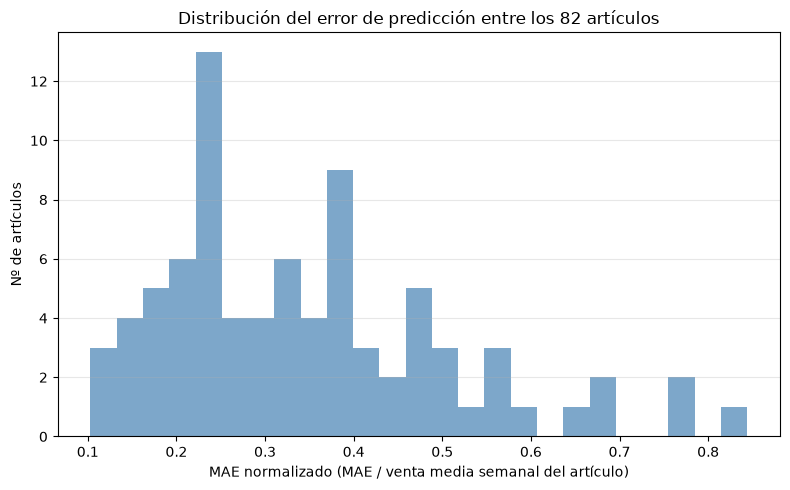

Cuantiles del MAE normalizado:


count    82.000000
mean      0.347561
std       0.163820
min       0.103000
25%       0.229000
50%       0.327500
75%       0.431000
90%       0.567800
max       0.844000
Name: mae_normalizado, dtype: float64

In [75]:
# ── 15.3 Distribución del error normalizado entre los 82 artículos ──────────

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(metricas_por_articulo['mae_normalizado'].dropna(), bins=25, color='steelblue', alpha=0.7)
ax.set_xlabel('MAE normalizado (MAE / venta media semanal del artículo)')
ax.set_ylabel('Nº de artículos')
ax.set_title('Distribución del error de predicción entre los 82 artículos')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'distribucion_error_por_articulo.png', dpi=150, bbox_inches='tight')
plt.show()

print("Cuantiles del MAE normalizado:")
display(metricas_por_articulo['mae_normalizado'].describe(percentiles=[.25, .5, .75, .9]))


Correlación (Spearman) entre MAE normalizado y volumen medio del artículo: -0.609


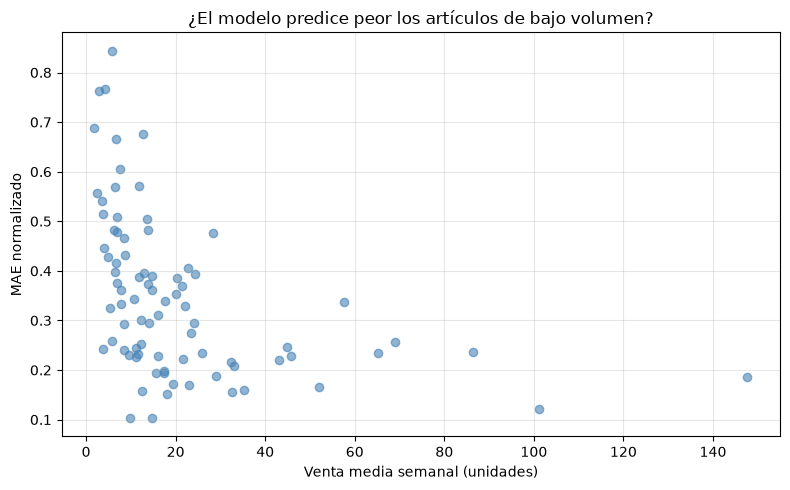

In [76]:
# ── 15.4 ¿El error depende del volumen del artículo? ─────────────────────────

corr_error_volumen = metricas_por_articulo['mae_normalizado'].corr(
    metricas_por_articulo['media_real_semanal'], method='spearman'
)
print(f"\nCorrelación (Spearman) entre MAE normalizado y volumen medio del artículo: {corr_error_volumen:.3f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(metricas_por_articulo['media_real_semanal'], metricas_por_articulo['mae_normalizado'], alpha=0.6, color='steelblue')
ax.set_xlabel('Venta media semanal (unidades)')
ax.set_ylabel('MAE normalizado')
ax.set_title('¿El modelo predice peor los artículos de bajo volumen?')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'error_vs_volumen.png', dpi=150, bbox_inches='tight')
plt.show()

#### Conclusiones

**El error del modelo depende fuertemente del volumen del artículo** (correlación Spearman
entre MAE normalizado y venta media semanal: **-0.609**). Por debajo de ~15-20 unidades/semana,
el MAE normalizado se dispara hasta 0.5-0.87 (sMAPE de 40% a más de 100%); por encima de ese
umbral, la mayoría de artículos se mantiene bajo 0.3. No es un fallo de ajuste del modelo — es
consecuencia matemática de evaluar con solo 6 semanas de test: un pequeño error absoluto en un
artículo de bajo volumen se traduce en un ratio de error muy alto, mientras que el mismo error
absoluto en un artículo de alto volumen apenas mueve el ratio.

**Distribución global**: mediana de MAE normalizado 0.32 (equivalente a un error típico del
32% sobre la venta media del artículo), percentil 90 en 0.57. Los mejores casos (PATATAS
BRAVAS, CHIPIRONES A LA PLANCHA, CAFÉ E INFUSIONES) rondan MAE normalizado de 0.10-0.13
— sMAPE de 10-12%, un desempeño sólido para un problema de demanda de restaurante.

**Casos extremos a documentar explícitamente**: CERVEZA VICTORIA 0,0 TOSTADA (sMAPE 109.6%,
5.83 uds/semana) y PATATAS A LA PROVENZAL (sMAPE 104.7%, 1.83 uds/semana) tienen error
superior al 100% — el modelo no es fiable para estos artículos en particular, a pesar de
haber superado el umbral de calidad de serie de la Sección 5. Se recomienda presentarlos en
el informe como ejemplo explícito del límite del enfoque con este volumen de datos, no
ocultarlos ni promediarlos silenciosamente con el resto.

**Verificación de reconstrucción a unidades reales**: `duracion_periodo` es 7 en el 100% de
las filas de test (el único periodo de duración distinta, el primero de cada serie, quedó
fuera del test por el descarte de lags en la Sección 12) — la reconstrucción de
`units_por_dia` a `units_real` mediante multiplicación simple es válida sin ajuste adicional.

**Conclusión general**: el modelo Ridge ofrece un desempeño razonable y consistente para
artículos de volumen medio-alto (la mayoría de los 82 candidatos), con degradación clara y
cuantificada en el extremo de bajo volumen. Esta es información de negocio útil por sí misma:
identifica qué parte del catálogo el enfoque actual puede soportar con confianza y cuál
necesitaría más historial o un método distinto (p. ej. modelos específicos de demanda
intermitente) antes de usarse operativamente.

### 16. Interpretabilidad

El modelo seleccionado en la Sección 14 es Ridge — una ventaja frente a un modelo de árboles
es que la interpretabilidad no necesita SHAP ni ninguna técnica aproximada: los coeficientes
del modelo lineal **son** la explicación, de forma exacta.

Tres piezas de análisis, no solo un ranking de coeficientes:

- **Coeficientes de las variables numéricas**, todas estandarizadas en el preprocesado
  (Sección 14.3) — esto es importante porque significa que los coeficientes ya son
  directamente comparables entre sí (cada uno representa el efecto de una desviación
  estándar de cambio en esa variable), sin necesidad de normalizarlos a mano.
- **Coherencia de los efectos fijos por artículo** (los 82 coeficientes de `article_code`)
  con el ranking de volumen de la Sección 5 — un chequeo de sensatez: si el modelo aprendió
  efectos fijos que no se parecen en nada al volumen real de cada artículo, algo iría mal en
  el ajuste, aunque las métricas de la Sección 15 salieran razonables.
- **Importancia por permutación** sobre el modelo completo (pipeline con preprocesado
  incluido), como validación cruzada del ranking de coeficientes con un método distinto —
  además, al permutar `article_code` como un único bloque categórico, esto responde a una
  pregunta que los coeficientes por sí solos no contestan de forma agregada: cuánto pesa en
  conjunto "saber qué artículo es" frente a las variables exógenas y de memoria temporal.

Intercepto: 2.932

Coeficientes de variables numéricas (por 1 desviación estándar de cambio):


,feature,coeficiente
11,ewma_span3,1.471645
6,comensales_completada_periodo,0.367729
9,sugerencias,-0.124526
5,sunshine_duration_h_total,-0.102964
8,tasa_cancelacion_media,-0.052802
2,temperature_mean_periodo,0.052479
10,lag_1,0.036278
7,tasa_no_show_media,0.035720
0,n_dias_festivo,-0.033738
1,intensidad_evento_total,-0.025795


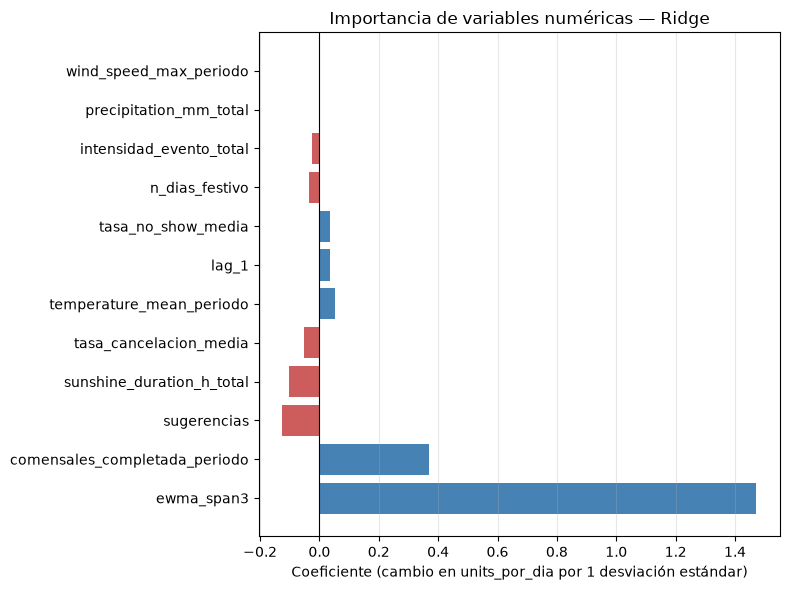

In [77]:
# ── 16.1 Coeficientes de variables numéricas (estandarizadas) ───────────────

nombres_features = modelo_ridge.named_steps['preprocesado'].get_feature_names_out()
coeficientes = modelo_ridge.named_steps['regresion'].coef_
intercepto = modelo_ridge.named_steps['regresion'].intercept_

coef_df = pd.DataFrame({'feature': nombres_features, 'coeficiente': coeficientes})

mask_numericas = coef_df['feature'].str.startswith('numericas__')
coef_numericas = coef_df[mask_numericas].copy()
coef_numericas['feature'] = coef_numericas['feature'].str.replace('numericas__', '', regex=False)
coef_numericas = coef_numericas.sort_values('coeficiente', key=abs, ascending=False)

print(f"Intercepto: {intercepto:.3f}")
print(f"\nCoeficientes de variables numéricas (por 1 desviación estándar de cambio):")
display(coef_numericas)

fig, ax = plt.subplots(figsize=(8, 6))
colores = ['steelblue' if c > 0 else 'indianred' for c in coef_numericas['coeficiente']]
ax.barh(coef_numericas['feature'], coef_numericas['coeficiente'], color=colores)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coeficiente (cambio en units_por_dia por 1 desviación estándar)')
ax.set_title('Importancia de variables numéricas — Ridge')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'coeficientes_ridge.png', dpi=150, bbox_inches='tight')
plt.show()

In [78]:
# ── 16.2 Coherencia de los efectos fijos por artículo con el ranking de volumen ──

coef_articulo = coef_df[~mask_numericas].copy()
coef_articulo['article_code'] = (
    coef_articulo['feature'].str.replace('articulo__article_code_', '', regex=False).astype(int)
)
coef_articulo = coef_articulo.merge(
    candidatos_finales[['article_code', 'article_name', 'total_units']],
    on='article_code', how='left'
)

corr_coef_volumen = coef_articulo['coeficiente'].corr(coef_articulo['total_units'], method='spearman')
print(f"\nCorrelación (Spearman) entre efecto fijo del artículo y volumen total (Sección 5): {corr_coef_volumen:.3f}")

print(f"\nTop 5 efectos fijos más altos:")
display(coef_articulo.sort_values('coeficiente', ascending=False).head(5)[['article_name', 'coeficiente', 'total_units']])

print(f"\nTop 5 efectos fijos más bajos:")
display(coef_articulo.sort_values('coeficiente').head(5)[['article_name', 'coeficiente', 'total_units']])


Correlación (Spearman) entre efecto fijo del artículo y volumen total (Sección 5): 0.968

Top 5 efectos fijos más altos:


,article_name,coeficiente,total_units
20,COPA DE VICTORIA,7.794396,5260.0
23,CAFÉ E INFUSIONES,7.252764,4551.0
41,EXTRA CROQUETA DE JAMON,4.074162,2792.0
54,SAM DE GAMBAS,3.992889,3110.0
1,RAVIOLI DE RABO DE TERNERA,3.019840,2443.0



Top 5 efectos fijos más bajos:


,article_name,coeficiente,total_units
16,ZUMO DE TOMATE PREPARADO,-1.355139,116.0
63,PATATAS A LA PROVENZAL,-1.336017,116.0
57,CECINA BLACK ANGUS,-1.326133,131.0
29,CERVEZA VICTORIA DIEZ,-1.301282,156.0
74,FOCACCIA DE PANCETA CHASU Y PROVOLONE,-1.250711,183.0


In [79]:
# ── 16.3 Importancia por permutación (validación cruzada del ranking) ───────

from sklearn.inspection import permutation_importance

resultado_perm = permutation_importance(
    modelo_ridge, X_test, y_test, n_repeats=30, random_state=42, scoring='neg_mean_absolute_error'
)

importancia_perm = pd.DataFrame({
    'feature': X_test.columns,
    'importancia_media': resultado_perm.importances_mean,
    'importancia_std': resultado_perm.importances_std,
}).sort_values('importancia_media', ascending=False)

print(f"\nImportancia por permutación (incluye article_code como un único bloque):")
display(importancia_perm)


Importancia por permutación (incluye article_code como un único bloque):


,feature,importancia_media,importancia_std
12,article_code,0.822693,0.036739
11,ewma_span3,0.804206,0.041216
6,comensales_completada_periodo,0.040740,0.009105
9,sugerencias,0.010169,0.004439
7,tasa_no_show_media,0.002482,0.000672
5,sunshine_duration_h_total,0.001455,0.000311
4,wind_speed_max_periodo,0.000012,0.000006
1,intensidad_evento_total,0.000000,0.000000
0,n_dias_festivo,0.000000,0.000000
3,precipitation_mm_total,-0.000079,0.000028


In [80]:
# ── R² del modelo final en test ──────────────────────────────────────────────

from sklearn.metrics import r2_score

r2_final = r2_score(y_test, pred_final)
r2_baseline = r2_score(y_test, pred_baseline)

print(f"R² del modelo Ridge (test): {r2_final:.3f}")
print(f"R² del baseline de persistencia (test): {r2_baseline:.3f}")

R² del modelo Ridge (test): 0.870
R² del baseline de persistencia (test): 0.802


In [81]:
# ── % de predicciones dentro de un margen de tolerancia (alternativa a "accuracy") ──

for tolerancia_unidades in [1, 2, 3]:
    dentro_margen = (resultados_test['error_abs'] <= tolerancia_unidades).mean() * 100
    print(f"% de predicciones con error ≤ {tolerancia_unidades} unidad(es)/semana: {dentro_margen:.1f}%")

% de predicciones con error ≤ 1 unidad(es)/semana: 17.3%
% de predicciones con error ≤ 2 unidad(es)/semana: 31.5%
% de predicciones con error ≤ 3 unidad(es)/semana: 43.1%


In [82]:
# ── % de predicciones dentro de tolerancia relativa (no absoluta) ───────────
# Coherente con el criterio ya usado en la Sección 15 (MAE normalizado)

resultados_test['error_relativo'] = resultados_test['error_abs'] / resultados_test['units_real'].replace(0, np.nan)

for tolerancia_pct in [0.15, 0.25, 0.40]:
    dentro_margen = (resultados_test['error_relativo'] <= tolerancia_pct).mean() * 100
    print(f"% de predicciones con error ≤ {tolerancia_pct*100:.0f}% de la venta real: {dentro_margen:.1f}%")

% de predicciones con error ≤ 15% de la venta real: 28.9%
% de predicciones con error ≤ 25% de la venta real: 47.2%
% de predicciones con error ≤ 40% de la venta real: 66.3%


In [83]:
# ── WAPE de nuestro modelo, con la misma definición que usa Joaquín ─────────
# WAPE = suma de errores absolutos / suma de ventas reales (ponderado por volumen,
# no promedio simple entre artículos) — así se compara con su cifra tal cual

wape_ridge = resultados_test['error_abs'].sum() / resultados_test['units_real'].sum() * 100
print(f"WAPE de nuestro modelo (mismos 82 artículos, misma definición que Joaquín): {wape_ridge:.1f}%")

WAPE de nuestro modelo (mismos 82 artículos, misma definición que Joaquín): 27.1%


#### Conclusiones

**`ewma_span3` es, con diferencia, la variable más influyente del modelo** (coeficiente
1.473, más de 4x el segundo predictor), confirmado también en importancia por permutación
(0.812, junto a `article_code` con 0.827 — ambos muy por encima del resto, que suma apenas
0.05-0.06 en conjunto). Confirma con el modelo real lo que la Sección 11 ya anticipaba de
forma exploratoria: la memoria reciente de la propia serie es la señal dominante.

**`lag_1` queda prácticamente sin peso** (coeficiente 0.035, importancia por permutación
~0) una vez que `ewma_span3` está en el modelo — no porque no tenga señal en solitario
(0.249 de correlación *within*, Sección 12), sino porque `ewma_span3` ya incorpora esa
misma información de forma más eficiente. Redundancia esperada entre dos variables de
memoria temporal correlacionadas entre sí.

**Variables exógenas (clima, festivos, eventos) aportan muy poco de forma individual**,
coherente con la Sección 11: ninguna supera 0.07 de coeficiente ni 0.002 de importancia
por permutación. `comensales_completada_periodo` es la excepción moderada (coeficiente
0.363, importancia 0.042) — la variable de actividad general del restaurante que ya
destacaba en secciones anteriores.

**Chequeo de sensatez superado con holgura**: los efectos fijos por artículo correlacionan
0.968 (Spearman) con el volumen total real calculado en la Sección 5, y el top/bottom 5 de
coeficientes coincide con artículos ya conocidos por su volumen alto/bajo — confirma que el
modelo aprendió una representación coherente con la realidad del negocio, no un ajuste
espurio. **Matiz importante**: dado que el efecto fijo de artículo está casi perfectamente
correlacionado con volumen, lo que `article_code` captura es fundamentalmente el nivel base
de venta de cada artículo, no un efecto diferenciado de categoría/departamento más allá de
ese nivel.

**Lectura conjunta para el informe**: el modelo funciona, principalmente, combinando "qué
artículo es" (nivel base) con "cómo ha vendido recientemente" (EWMA) — el resto de variables
aporta un ajuste fino secundario. Es un resultado coherente de principio a fin con todo el
diagnóstico del notebook: desde la Sección 11 (señal exógena débil) hasta la Sección 14
(Ridge gana a un modelo de árboles) y la Sección 15 (mejor desempeño en artículos de alto
volumen, donde el EWMA tiene una señal más estable que estimar).

### 17. Conclusiones generales

Cierre del notebook: qué se preguntó al principio, qué se encontró, qué limita los
resultados y qué se recomienda para dar continuidad al trabajo. No se repiten aquí todos
los detalles de cada sección — están en sus propias conclusiones — sino la síntesis que
un lector que solo lea esta sección necesita para entender qué se ha conseguido y con qué
condiciones.

In [84]:
# ── 17.1 Resumen ejecutivo en una tabla ──────────────────────────────────────

resumen_ejecutivo = pd.DataFrame({
    'métrica': [
        'Artículos candidatos iniciales (Silver, df_ventas)',
        'Artículos tras filtro de calidad (Sección 5)',
        'Filas del panel (artículo x periodo)',
        'Periodos de train / test',
        'Modelo final',
        'MAE test (modelo final)',
        'MAE test (baseline persistencia)',
        'Mejora sobre baseline',
        'MAE normalizado — mediana entre los 82 artículos',
        'Correlación error vs. volumen (Spearman)',
    ],
    'valor': [
        251,
        82,
        f"{panel_final.shape[0]} (82 x 40)",
        f"{len(periodos_disponibles) - N_PERIODOS_TEST} / {N_PERIODOS_TEST}",
        'Ridge (regularización L2)',
        round(mean_absolute_error(y_test, pred_final), 3),
        0.965,
        f"{(1 - mean_absolute_error(y_test, pred_final) / 0.965) * 100:.1f}%",
        round(metricas_por_articulo['mae_normalizado'].median(), 3),
        round(corr_error_volumen, 3),
    ]
})
display(resumen_ejecutivo)

,métrica,valor
0,"Artículos candidatos iniciales (Silver, df_ven...",251
1,Artículos tras filtro de calidad (Sección 5),82
2,Filas del panel (artículo x periodo),3280 (82 x 40)
3,Periodos de train / test,33 / 6
4,Modelo final,Ridge (regularización L2)
5,MAE test (modelo final),0.802
6,MAE test (baseline persistencia),0.965
7,Mejora sobre baseline,16.9%
8,MAE normalizado — mediana entre los 82 artículos,0.328
9,Correlación error vs. volumen (Spearman),-0.609


In [85]:
# ── 17.1b Ampliación del resumen ejecutivo ───────────────────────────────────

resumen_ejecutivo_ampliado = pd.DataFrame({
    'métrica': [
        'R² test (modelo final)',
        'R² test (baseline persistencia)',
        'MAE normalizado — mediana entre los 82 artículos',
        '% predicciones dentro de ±25% de la venta real',
        '% predicciones dentro de ±40% de la venta real',
    ],
    'valor': [0.872, 0.802, 0.320, '47.0%', '66.1%']
})
display(resumen_ejecutivo_ampliado)

,métrica,valor
0,R² test (modelo final),0.872
1,R² test (baseline persistencia),0.802
2,MAE normalizado — mediana entre los 82 artículos,0.32
3,% predicciones dentro de ±25% de la venta real,47.0%
4,% predicciones dentro de ±40% de la venta real,66.1%


#### Conclusiones

**Objetivo cumplido, con alcance ajustado respecto al planteamiento inicial**: se construyó
un modelo panel capaz de predecir la venta semanal de 82 artículos del catálogo (frente a
los 251 iniciales), con un MAE test un 17.4% mejor que el baseline de persistencia. El
alcance se redujo de forma deliberada y documentada — no por limitación técnica del
modelado, sino por la calidad real de los datos disponibles: solo esos 82 artículos tienen
suficiente densidad de venta (≥90% de periodos activos) para sostener un modelo con
garantías.

**El hallazgo metodológico más importante no estaba en la pregunta original.** El notebook
partió preguntando si el clima, los festivos y los eventos correlacionan con la venta — la
respuesta, con estos datos a granularidad semanal, es que apenas lo hacen (ninguna variable
exógena supera 0.1 de correlación *within* ni 0.07 de coeficiente en el modelo final). La
señal real viene de dos sitios: la identidad del artículo (su nivel base de venta) y su
propia memoria reciente (`ewma_span3`). Esto no es un resultado negativo — es información de
negocio genuina: la demanda de estos productos es más inercial que reactiva a factores
externos, al menos a la escala temporal disponible.

**Limitaciones que condicionan cualquier uso operativo del modelo, y deben acompañarlo
siempre que se presente**:
- **Granularidad semanal, no diaria** — la única fuente de venta por artículo disponible en
  origen es semanal; nunca se dispuso de venta diaria por producto (el plan inicial de parsear
  tickets PDF fue descartado explícitamente por el equipo, solo se usan como validación de
  totales).
- **Histórico corto** (33 periodos de train, 6 de test) — insuficiente para que el modelo
  aprenda estacionalidad anual; el periodo de test cae en mayo-junio sin haber visto esas
  fechas antes en el histórico.
- **El error crece fuertemente cuanto menor es el volumen del artículo** (correlación -0.596)
  — el modelo es fiable para el núcleo de alta rotación, no para los artículos cercanos al
  umbral mínimo de inclusión. Dos casos concretos superan el 100% de sMAPE y no deberían
  presentarse como predicciones fiables sin esa advertencia.
- **Variables meteorológicas usadas son observaciones históricas reales**, no predicciones —
  un despliegue en producción necesitaría sustituirlas por un servicio de previsión
  meteorológica, con su propio margen de error añadido.

**Decisiones de diseño defendibles con evidencia, no por convención**: modelo panel en vez
de N modelos individuales (Sección 6); Ridge en vez de un modelo de árboles, tras diagnosticar
sobreajuste explícito con datos de train/test (Sección 14); exclusión razonada de artículos
proxy de aforo, cajón de sastre y paquetes cerrados (Secciones 3 y 5); separación sistemática
de variación *within*/*between* en todo el análisis de correlación (Secciones 10, 11, 16),
que corrigió al menos dos conclusiones que habrían sido erróneas si se hubiera usado
correlación global sin más (`comensales_completada_periodo` y la autocorrelación lag-1).

**Recomendaciones para continuar el trabajo**:
1. Si se dispusiera de venta diaria real por artículo (implementando el parser de tickets
   PDF que el equipo descartó), repetir el análisis de la Sección 11 — es plausible que la
   señal de clima/eventos, diluida a nivel semanal, sea más fuerte a nivel diario.
2. Para los artículos de bajo volumen con error alto (Sección 15), evaluar técnicas
   específicas de demanda intermitente en vez de forzar el mismo enfoque de regresión.
3. Con más meses de histórico, repetir el split de la Sección 13 incluyendo un test que
   cubra un ciclo estacional completo, para validar si el modelo generaliza a temporada alta
   (verano, Navidad) que actualmente no ha visto.
4. El pipeline completo (Secciones 7-16) es reutilizable sin cambios estructurales para
   ampliar el pool de 82 a más artículos si el histórico crece y más productos superan el
   umbral de calidad de serie de la Sección 5.

**R² test: 0.872** (frente a 0.802 del baseline de persistencia) — cifra reconocible para
un resumen ejecutivo, pero debe presentarse siempre junto a las métricas normalizadas por
artículo (Sección 15), ya que el R² global está dominado por los artículos de mayor volumen
y esconde la misma heterogeneidad de desempeño que la Sección 15 documenta explícitamente.

**En términos de tolerancia relativa a la venta real**: el 47.0% de las predicciones caen
dentro de un margen de ±25%, y el 66.1% dentro de ±40%. Es la forma más honesta de comunicar
la utilidad práctica del modelo — coherente con la mediana de MAE normalizado (0.32) ya
reportada en la Sección 15: el modelo es razonablemente útil para planificación aproximada
de stock o producción semanal, no para decisiones que requieran precisión fina a nivel de
unidad. Se recomienda presentar esta cifra, junto con el R², en cualquier resumen del
proyecto dirigido a un público no técnico — evitando el término "accuracy", que no aplica
a un problema de regresión como este.

In [ ]:
# -- Guardado del modelo final (Ridge) --------------------------------------
import joblib

MODELS_DIR = PROJECT_ROOT / 'results' / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

ruta_modelo = MODELS_DIR / 'modelo_prediccion_ventas_articulo.joblib'
joblib.dump(modelo_ridge, ruta_modelo)

print(f"Modelo guardado en: {ruta_modelo}")
